## 0 Baseline from Foundation

In [35]:
#Baseline configuration
out_dir = 'out-shakespeare-baseline'
eval_interval = 200
eval_iters = 200
log_interval = 10
always_save_checkpoint = False
wandb_log = False
wandb_project = 'nanoGPT-assignment'
wandb_run_name = 'baseline'
dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2
learning_rate = 1e-3
max_iters = 1000
lr_decay_iters = 5000
min_lr = 1e-4
beta2 = 0.99
warmup_iters = 100
weight_decay = 1e-1
device = 'cuda' # change to 'cuda' if you have a GPU
compile = False # set True only on Linux with GPU

#for testing
num_samples=3
max_new_tokens=500

all_runs = {}
all_samples = {}

### 0.1 Prepare the Dataset

In [36]:
"""
Prepare the Shakespeare dataset for character-level language modeling.
So instead of encoding with GPT-2 BPE tokens, we just map characters to ints.
Will save train.bin, val.bin containing the ids, and meta.pkl containing the
encoder and decoder and some other related info.
"""
import os
import pickle
import requests
import numpy as np



def prepare_dataset(
    dataset_name,
    default_dataset=True,   # "shakespeare" or "custom"
    use_char=True,        # "char" or "bpe"
    custom_input_file=None,
    train_split=0.9,
    download_if_missing=True,
    shakespeare_url="https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt",
    bpe_vocab_size=2000,
    bpe_min_frequency=2,
    extra_text_for_vocab = "", #For task 2
):
    # download the tiny shakespeare dataset
    directory_path = os.path.join(os.path.abspath(''),"data", dataset_name)
    input_file_path = os.path.join(directory_path, 'input.txt')

    print(directory_path)

    if default_dataset:
        if not os.path.exists(directory_path):
            os.makedirs(directory_path)
        if not os.path.exists(input_file_path):
            data_url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
            with open(input_file_path, 'w') as f:
                f.write(requests.get(data_url).text)
    else:
        if custom_input_file is None:
            raise ValueError("For dataset_mode='custom', you must provide custom_input_file")

        if not os.path.exists(custom_input_file):
            raise FileNotFoundError(f"Custom input file not found: {custom_input_file}")

        with open(custom_input_file, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()

        with open(input_file_path, "w", encoding="utf-8") as f:
            f.write(text)

    with open(input_file_path, 'r', encoding='utf-8') as f:
        data = f.read()
    print(f"length of dataset in characters: {len(data):,}")
    if use_char:
        # get all the unique characters that occur in this text
        vocab_source = data + extra_text_for_vocab
        chars = sorted(list(set(vocab_source)))
        vocab_size = len(chars)
        print("all the unique characters:", ''.join(chars))
        print(f"vocab size: {vocab_size:,}")

        # create a mapping from characters to integers
        stoi = { ch:i for i,ch in enumerate(chars) }
        itos = { i:ch for i,ch in enumerate(chars) }
        def encode(s):
            return [stoi[c] for c in s] # encoder: take a string, output a list of integers
        def decode(l):
            return ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

        # create the train and test splits
        n = len(data)
        train_data = data[:int(n*train_split)]
        val_data = data[int(n*train_split):]

        # encode both to integers
        train_ids = encode(train_data)
        val_ids = encode(val_data)
        print(f"train has {len(train_ids):,} tokens")
        print(f"val has {len(val_ids):,} tokens")

        # export to bin files
        train_ids = np.array(train_ids, dtype=np.uint16)
        val_ids = np.array(val_ids, dtype=np.uint16)
        train_ids.tofile(os.path.join(directory_path, 'train.bin'))
        val_ids.tofile(os.path.join(directory_path, 'val.bin'))

        # save the meta information as well, to help us encode/decode later
        meta = {
            'vocab_size': vocab_size,
            'itos': itos,
            'stoi': stoi,
        }
        with open(os.path.join(directory_path, 'meta.pkl'), 'wb') as f:
            pickle.dump(meta, f)

        # length of dataset in characters:  1115394
        # all the unique characters:
        #  !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
        # vocab size: 65
        # train has 1003854 tokens
        # val has 111540 tokens
    else:
        try:
            from tokenizers import Tokenizer
            from tokenizers.models import BPE
            from tokenizers.trainers import BpeTrainer
            from tokenizers.pre_tokenizers import ByteLevel
            from tokenizers.decoders import ByteLevel as ByteLevelDecoder
        except ImportError:
            raise ImportError(
                "BPE mode requires the 'tokenizers' package.\n"
                "Install it in the notebook with:\n"
                "!pip install tokenizers"
            )

        tokenizer_path = os.path.join(directory_path, "tokenizer.json")

        tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
        tokenizer.pre_tokenizer = ByteLevel()
        tokenizer.decoder = ByteLevelDecoder()

        trainer = BpeTrainer(
            vocab_size=bpe_vocab_size,
            min_frequency=bpe_min_frequency,
            special_tokens=["[UNK]"]
        )

        tokenizer.train([input_file_path], trainer)
        tokenizer.save(tokenizer_path)

        ids = tokenizer.encode(data).ids
        vocab_size = tokenizer.get_vocab_size()

        print(f"BPE vocab size: {vocab_size:,}")
        print(f"Total BPE tokens: {len(ids):,}")

        n = len(ids)
        train_ids = np.array(ids[:int(n * train_split)], dtype=np.uint16)
        val_ids = np.array(ids[int(n * train_split):], dtype=np.uint16)

        print(f"Train has {len(train_ids):,} tokens")
        print(f"Val has {len(val_ids):,} tokens")

        train_ids.tofile(os.path.join(directory_path, "train.bin"))
        val_ids.tofile(os.path.join(directory_path, "val.bin"))

        meta = {
            "vocab_size": vocab_size,
            "tokenizer_type": "bpe",
            "tokenizer_path": "tokenizer.json",
            "dataset_mode": "bpe",
            "bpe_vocab_size": bpe_vocab_size,
            "bpe_min_frequency": bpe_min_frequency,
        }

        with open(os.path.join(directory_path, "meta.pkl"), "wb") as f:
            pickle.dump(meta, f)

        print("Saved BPE dataset files.")

    print("\nDone.")
    return {
        "dataset_dir": directory_path,
        "input_file_path": input_file_path,
        "tokenizer_mode": use_char,
        "dataset_mode": default_dataset,
    }


### 0.2 Model from nanoGPT

In [37]:
"""
Full definition of a GPT Language Model, all of it in this single file.
References:
1) the official GPT-2 TensorFlow implementation released by OpenAI:
https://github.com/openai/gpt-2/blob/master/src/model.py
2) huggingface/transformers PyTorch implementation:
https://github.com/huggingface/transformers/blob/main/src/transformers/models/gpt2/modeling_gpt2.py
"""

import math
import inspect
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.nn import functional as F

class LayerNorm(nn.Module):
    """ LayerNorm but with an optional bias. PyTorch doesn't support simply bias=False """

    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, input):
        return F.layer_norm(input, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        # regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        # flash attention make GPU go brrrrr but support is only in PyTorch >= 2.0
        self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        if not self.flash:
            print("WARNING: using slow attention. Flash Attention requires PyTorch >= 2.0")
            # causal mask to ensure that attention is only applied to the left in the input sequence
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        # causal self-attention; Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        if self.flash:
            # efficient attention using Flash Attention CUDA kernels
            y = torch.nn.functional.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.dropout if self.training else 0, is_causal=True)
        else:
            # manual implementation of attention
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side

        # output projection
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50304 # GPT-2 vocab_size of 50257, padded up to nearest multiple of 64 for efficiency
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = True # True: bias in Linears and LayerNorms, like GPT-2. False: a bit better and faster

class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.vocab_size is not None
        assert config.block_size is not None
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.n_embd, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        # with weight tying when using torch.compile() some warnings get generated:
        # "UserWarning: functional_call was passed multiple values for tied weights.
        # This behavior is deprecated and will be an error in future versions"
        # not 100% sure what this is, so far seems to be harmless. TODO investigate
        self.transformer.wte.weight = self.lm_head.weight # https://paperswithcode.com/method/weight-tying

        # init all weights
        self.apply(self._init_weights)
        # apply special scaled init to the residual projections, per GPT-2 paper
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * config.n_layer))

        # report number of parameters
        print("number of parameters: %.2fM" % (self.get_num_params()/1e6,))

    def get_num_params(self, non_embedding=True):
        """
        Return the number of parameters in the model.
        For non-embedding count (default), the position embeddings get subtracted.
        The token embeddings would too, except due to the parameter sharing these
        params are actually used as weights in the final layer, so we include them.
        """
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wpe.weight.numel()
        return n_params

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size, f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)

        # forward the GPT model itself
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            # if we are given some desired targets also calculate the loss
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            # inference-time mini-optimization: only forward the lm_head on the very last position
            logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
            loss = None

        return logits, loss

    def crop_block_size(self, block_size):
        # model surgery to decrease the block size if necessary
        # e.g. we may load the GPT2 pretrained model checkpoint (block size 1024)
        # but want to use a smaller block size for some smaller, simpler model
        assert block_size <= self.config.block_size
        self.config.block_size = block_size
        self.transformer.wpe.weight = nn.Parameter(self.transformer.wpe.weight[:block_size])
        for block in self.transformer.h:
            if hasattr(block.attn, 'bias'):
                block.attn.bias = block.attn.bias[:,:,:block_size,:block_size]

    @classmethod
    def from_pretrained(cls, model_type, override_args=None):
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        override_args = override_args or {} # default to empty dict
        # only dropout can be overridden see more notes below
        assert all(k == 'dropout' for k in override_args)
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        print("forcing vocab_size=50257, block_size=1024, bias=True")
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        config_args['bias'] = True # always True for GPT model checkpoints
        # we can override the dropout rate, if desired
        if 'dropout' in override_args:
            print(f"overriding dropout rate to {override_args['dropout']}")
            config_args['dropout'] = override_args['dropout']
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

    def configure_optimizers(self, weight_decay, learning_rate, betas, device_type):
        # start with all of the candidate parameters
        param_dict = {pn: p for pn, p in self.named_parameters()}
        # filter out those that do not require grad
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
        # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
        print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")
        # Create AdamW optimizer and use the fused version if it is available
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == 'cuda'
        extra_args = dict(fused=True) if use_fused else dict()
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas, **extra_args)
        print(f"using fused AdamW: {use_fused}")

        return optimizer

    def estimate_mfu(self, fwdbwd_per_iter, dt):
        """ estimate model flops utilization (MFU) in units of A100 bfloat16 peak FLOPS """
        # first estimate the number of flops we do per iteration.
        # see PaLM paper Appendix B as ref: https://arxiv.org/abs/2204.02311
        N = self.get_num_params()
        cfg = self.config
        L, H, Q, T = cfg.n_layer, cfg.n_head, cfg.n_embd//cfg.n_head, cfg.block_size
        flops_per_token = 6*N + 12*L*H*Q*T
        flops_per_fwdbwd = flops_per_token * T
        flops_per_iter = flops_per_fwdbwd * fwdbwd_per_iter
        # express our flops throughput as ratio of A100 bfloat16 peak flops
        flops_achieved = flops_per_iter * (1.0/dt) # per second
        flops_promised = 312e12 # A100 GPU bfloat16 peak flops is 312 TFLOPS
        mfu = flops_achieved / flops_promised
        return mfu

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Take a conditioning sequence of indices idx (LongTensor of shape (b,t)) and complete
        the sequence max_new_tokens times, feeding the predictions back into the model each time.
        Most likely you'll want to make sure to be in model.eval() mode of operation for this.
        """
        for _ in range(max_new_tokens):
            # if the sequence context is growing too long we must crop it at block_size
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            # forward the model to get the logits for the index in the sequence
            logits, _ = self(idx_cond)
            # pluck the logits at the final step and scale by desired temperature
            logits = logits[:, -1, :] / temperature
            # optionally crop the logits to only the top k options
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            # apply softmax to convert logits to (normalized) probabilities
            probs = F.softmax(logits, dim=-1)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)
            # append sampled index to the running sequence and continue
            idx = torch.cat((idx, idx_next), dim=1)

        return idx


### 0.3 Training Function

In [38]:
"""
This training script can be run both on a single gpu in debug mode,
and also in a larger training run with distributed data parallel (ddp).

To run on a single GPU, example:
$ python train.py --batch_size=32 --compile=False

To run with DDP on 4 gpus on 1 node, example:
$ torchrun --standalone --nproc_per_node=4 train.py

To run with DDP on 4 gpus across 2 nodes, example:
- Run on the first (master) node with example IP 123.456.123.456:
$ torchrun --nproc_per_node=8 --nnodes=2 --node_rank=0 --master_addr=123.456.123.456 --master_port=1234 train.py
- Run on the worker node:
$ torchrun --nproc_per_node=8 --nnodes=2 --node_rank=1 --master_addr=123.456.123.456 --master_port=1234 train.py
(If your cluster does not have Infiniband interconnect prepend NCCL_IB_DISABLE=1)
"""

import os
import time
import math
import pickle
from contextlib import nullcontext

import numpy as np
import torch
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group

# -----------------------------------------------------------------------------
# default config values designed to train a gpt2 (124M) on OpenWebText
# I/O
eval_only = False # if True, script exits right after the first eval
init_from = 'scratch' # 'scratch' or 'resume' or 'gpt2*'
# model
bias = False # do we use bias inside LayerNorm and Linear layers?
# adamw optimizer
beta1 = 0.9
grad_clip = 1.0 # clip gradients at this value, or disable if == 0.0
# learning rate decay settings
decay_lr = True # whether to decay the learning rate
lr_decay_iters = 600000 # should be ~= max_iters per Chinchilla
# DDP settings
backend = 'nccl' # 'nccl', 'gloo', etc.
# system
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler

def expand_state_dict_vocab(state_dict, new_vocab_size):
    tok_key = None
    head_key = None

    for k in state_dict.keys():
        if k.endswith("transformer.wte.weight") or k.endswith("wte.weight"):
            tok_key = k
        if k.endswith("lm_head.weight"):
            head_key = k

    if tok_key is None or head_key is None:
        raise ValueError("Could not find embedding or lm_head weights in checkpoint.")

    old_tok = state_dict[tok_key]
    old_head = state_dict[head_key]

    old_vocab_size, n_embd = old_tok.shape
    if new_vocab_size == old_vocab_size:
        return state_dict

    if new_vocab_size < old_vocab_size:
        raise ValueError(f"New vocab size {new_vocab_size} is smaller than old vocab size {old_vocab_size}.")

    new_tok = old_tok.new_empty((new_vocab_size, n_embd))
    new_head = old_head.new_empty((new_vocab_size, n_embd))

    new_tok[:old_vocab_size] = old_tok
    new_head[:old_vocab_size] = old_head

    torch.nn.init.normal_(new_tok[old_vocab_size:], mean=0.0, std=0.02)
    torch.nn.init.normal_(new_head[old_vocab_size:], mean=0.0, std=0.02)

    state_dict[tok_key] = new_tok
    state_dict[head_key] = new_head
    return state_dict

def run():
    global gradient_accumulation_steps, device
    # -----------------------------------------------------------------------------
    config_keys = [k for k,v in globals().items() if not k.startswith('_') and isinstance(v, (int, float, bool, str))]
    config = {k: globals()[k] for k in config_keys} # will be useful for logging
    # -----------------------------------------------------------------------------

    # various inits, derived attributes, I/O setup
    ddp = int(os.environ.get('RANK', -1)) != -1 # is this a ddp run?
    if ddp:
        init_process_group(backend=backend)
        ddp_rank = int(os.environ['RANK'])
        ddp_local_rank = int(os.environ['LOCAL_RANK'])
        ddp_world_size = int(os.environ['WORLD_SIZE'])
        device = f'cuda:{ddp_local_rank}'
        torch.cuda.set_device(device)
        master_process = ddp_rank == 0 # this process will do logging, checkpointing etc.
        seed_offset = ddp_rank # each process gets a different seed
        # world_size number of processes will be training simultaneously, so we can scale
        # down the desired gradient accumulation iterations per process proportionally
        assert gradient_accumulation_steps % ddp_world_size == 0
        gradient_accumulation_steps //= ddp_world_size
    else:
        # if not ddp, we are running on a single gpu, and one process
        master_process = True
        seed_offset = 0
        ddp_world_size = 1
    tokens_per_iter = gradient_accumulation_steps * ddp_world_size * batch_size * block_size
    print(f"tokens per iteration will be: {tokens_per_iter:,}")

    if master_process:
        os.makedirs(os.path.join('models', out_dir), exist_ok=True)
    torch.manual_seed(1337 + seed_offset)
    torch.backends.cuda.matmul.allow_tf32 = True # allow tf32 on matmul
    torch.backends.cudnn.allow_tf32 = True # allow tf32 on cudnn
    device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
    # note: float16 data type will automatically use a GradScaler
    ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
    ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

    # poor man's data loader
    data_dir = os.path.join('data', dataset)
    def get_batch(split):
        # We recreate np.memmap every batch to avoid a memory leak, as per
        # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
        if split == 'train':
            data = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
        else:
            data = np.memmap(os.path.join(data_dir, 'val.bin'), dtype=np.uint16, mode='r')
        ix = torch.randint(len(data) - block_size, (batch_size,))
        x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
        y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
        if device_type == 'cuda':
            # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
            x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
        else:
            x, y = x.to(device), y.to(device)
        return x, y

    # init these up here, can override if init_from='resume' (i.e. from a checkpoint)
    iter_num = 0
    best_val_loss = 1e9

    # attempt to derive vocab_size from the dataset
    meta_path = os.path.join(data_dir, 'meta.pkl')
    meta_vocab_size = None
    if os.path.exists(meta_path):
        with open(meta_path, 'rb') as f:
            meta = pickle.load(f)
        meta_vocab_size = meta['vocab_size']
        print(f"found vocab_size = {meta_vocab_size} (inside {meta_path})")

    # model init
    model_args = dict(n_layer=n_layer, n_head=n_head, n_embd=n_embd, block_size=block_size,
                    bias=bias, vocab_size=None, dropout=dropout) # start with model_args from command line
    if init_from == 'scratch':
        # init a new model from scratch
        print("Initializing a new model from scratch")
        # determine the vocab size we'll use for from-scratch training
        if meta_vocab_size is None:
            print("defaulting to vocab_size of GPT-2 to 50304 (50257 rounded up for efficiency)")
        model_args['vocab_size'] = meta_vocab_size if meta_vocab_size is not None else 50304
        gptconf = GPTConfig(**model_args)
        model = GPT(gptconf)
    elif init_from == 'resume':
        print(f"Resuming training from {out_dir}")
        # resume training from a checkpoint.
        ckpt_path = os.path.join('models', out_dir, 'ckpt.pt')
        checkpoint = torch.load(ckpt_path, map_location=device)
        checkpoint_model_args = checkpoint['model_args']
        # force these config attributes to be equal otherwise we can't even resume training
        # the rest of the attributes (e.g. dropout) can stay as desired from command line
        for k in ['n_layer', 'n_head', 'n_embd', 'block_size', 'bias', 'vocab_size']:
            model_args[k] = checkpoint_model_args[k]
        # create the model
        gptconf = GPTConfig(**model_args)
        model = GPT(gptconf)
        state_dict = checkpoint['model']
        # fix the keys of the state dictionary :(
        # honestly no idea how checkpoints sometimes get this prefix, have to debug more
        unwanted_prefix = '_orig_mod.'
        for k,v in list(state_dict.items()):
            if k.startswith(unwanted_prefix):
                state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
        model.load_state_dict(state_dict)
        iter_num = checkpoint['iter_num']
        best_val_loss = checkpoint['best_val_loss']
    elif init_from.startswith('gpt2'):
        print(f"Initializing from OpenAI GPT-2 weights: {init_from}")
        # initialize from OpenAI GPT-2 weights
        override_args = dict(dropout=dropout)
        model = GPT.from_pretrained(init_from, override_args)
        # read off the created config params, so we can store them into checkpoint correctly
        for k in ['n_layer', 'n_head', 'n_embd', 'block_size', 'bias', 'vocab_size']:
            model_args[k] = getattr(model.config, k)
    elif init_from == 'pretrained':
        print(f"Initializing from pretrained checkpoint: {pretrained_ckpt_path}")
        checkpoint = torch.load(pretrained_ckpt_path, map_location=device, weights_only=False)
        checkpoint_model_args = checkpoint['model_args']

        # architecture must match pretrained checkpoint
        for k in ['n_layer', 'n_head', 'n_embd', 'block_size', 'bias']:
            model_args[k] = checkpoint_model_args[k]

        # use current dataset vocab size if available, otherwise fallback to checkpoint vocab
        model_args['vocab_size'] = meta_vocab_size if meta_vocab_size is not None else checkpoint_model_args['vocab_size']

        gptconf = GPTConfig(**model_args)
        model = GPT(gptconf)

        state_dict = checkpoint['model']

        unwanted_prefix = '_orig_mod.'
        for k, v in list(state_dict.items()):
            if k.startswith(unwanted_prefix):
                state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)

        # expand embedding/lm_head if SFT vocab is larger
        state_dict = expand_state_dict_vocab(state_dict, model_args['vocab_size'])

        model.load_state_dict(state_dict, strict=False)

        iter_num = 0
        best_val_loss = 1e9
    # crop down the model block size if desired, using model surgery
    if block_size < model.config.block_size:
        model.crop_block_size(block_size)
        model_args['block_size'] = block_size # so that the checkpoint will have the right value
    model.to(device)

    # initialize a GradScaler. If enabled=False scaler is a no-op
    scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

    # optimizer
    optimizer = model.configure_optimizers(weight_decay, learning_rate, (beta1, beta2), device_type)
    if init_from == 'resume':
        optimizer.load_state_dict(checkpoint['optimizer'])
    checkpoint = None # free up memory

    # compile the model
    if compile:
        print("compiling the model... (takes a ~minute)")
        unoptimized_model = model
        model = torch.compile(model) # requires PyTorch 2.0

    # wrap model into DDP container
    if ddp:
        model = DDP(model, device_ids=[ddp_local_rank])

    # helps estimate an arbitrarily accurate loss over either split using many batches
    @torch.no_grad()
    def estimate_loss():
        out = {}
        model.eval()
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
        model.train()
        return out

    # learning rate decay scheduler (cosine with warmup)
    def get_lr(it):
        # 1) linear warmup for warmup_iters steps
        if it < warmup_iters:
            return learning_rate * (it + 1) / (warmup_iters + 1)
        # 2) if it > lr_decay_iters, return min learning rate
        if it > lr_decay_iters:
            return min_lr
        # 3) in between, use cosine decay down to min learning rate
        decay_ratio = (it - warmup_iters) / (lr_decay_iters - warmup_iters)
        assert 0 <= decay_ratio <= 1
        coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff ranges 0..1
        return min_lr + coeff * (learning_rate - min_lr)

    # logging
    if wandb_log and master_process:
        import wandb
        wandb.init(project=wandb_project, name=wandb_run_name, config=config)

    # training loop
    X, Y = get_batch('train') # fetch the very first batch
    # Task 3 / Experiment 6: record full fine-tuning wall-clock time for the LoRA-vs-full-FT comparison.
    run_started_at = time.time()
    t0 = run_started_at
    local_iter_num = 0 # number of iterations in the lifetime of this process
    raw_model = model.module if ddp else model # unwrap DDP container if needed
    running_mfu = -1.0

    history = {
        "steps": [],
        "train_loss": [],
        "val_loss": []
    }
    
    while True:

        # determine and set the learning rate for this iteration
        lr = get_lr(iter_num) if decay_lr else learning_rate
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        # evaluate the loss on train/val sets and write checkpoints
        if iter_num % eval_interval == 0 and master_process:
            losses = estimate_loss()
            history["steps"].append(iter_num)
            history["train_loss"].append(float(losses["train"]))
            history["val_loss"].append(float(losses["val"]))

            print(f"step {iter_num}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
            if wandb_log:
                wandb.log({
                    "iter": iter_num,
                    "train/loss": losses['train'],
                    "val/loss": losses['val'],
                    "lr": lr,
                    "mfu": running_mfu*100, # convert to percentage
                })
            if losses['val'] < best_val_loss or always_save_checkpoint:
                best_val_loss = losses['val']
                if iter_num > 0:
                    checkpoint = {
                        'model': raw_model.state_dict(),
                        'optimizer': optimizer.state_dict(),
                        'model_args': model_args,
                        'iter_num': iter_num,
                        'best_val_loss': best_val_loss,
                        'config': config,
                    }
                    print(f"saving checkpoint to {out_dir}")
                    torch.save(checkpoint, os.path.join('models', out_dir, 'ckpt.pt'))
        if iter_num == 0 and eval_only:
            break

        # forward backward update, with optional gradient accumulation to simulate larger batch size
        # and using the GradScaler if data type is float16
        for micro_step in range(gradient_accumulation_steps):
            if ddp:
                # in DDP training we only need to sync gradients at the last micro step.
                # the official way to do this is with model.no_sync() context manager, but
                # I really dislike that this bloats the code and forces us to repeat code
                # looking at the source of that context manager, it just toggles this variable
                model.require_backward_grad_sync = (micro_step == gradient_accumulation_steps - 1)
            with ctx:
                logits, loss = model(X, Y)
                loss = loss / gradient_accumulation_steps # scale the loss to account for gradient accumulation
            # immediately async prefetch next batch while model is doing the forward pass on the GPU
            X, Y = get_batch('train')
            # backward pass, with gradient scaling if training in fp16
            scaler.scale(loss).backward()
        # clip the gradient
        if grad_clip != 0.0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        # step the optimizer and scaler if training in fp16
        scaler.step(optimizer)
        scaler.update()
        # flush the gradients as soon as we can, no need for this memory anymore
        optimizer.zero_grad(set_to_none=True)

        # timing and logging
        t1 = time.time()
        dt = t1 - t0
        t0 = t1
        if iter_num % log_interval == 0 and master_process:
            # get loss as float. note: this is a CPU-GPU sync point
            # scale up to undo the division above, approximating the true total loss (exact would have been a sum)
            lossf = loss.item() * gradient_accumulation_steps
            if local_iter_num >= 5: # let the training loop settle a bit
                mfu = raw_model.estimate_mfu(batch_size * gradient_accumulation_steps, dt)
                running_mfu = mfu if running_mfu == -1.0 else 0.9*running_mfu + 0.1*mfu
            print(f"iter {iter_num}: loss {lossf:.4f}, time {dt*1000:.2f}ms, mfu {running_mfu*100:.2f}%")
        iter_num += 1
        local_iter_num += 1

        # termination conditions
        if iter_num > max_iters:
            break

    if ddp:
        destroy_process_group()

    # Task 3 / Experiment 6: keep runtime in the returned history so later analysis cells can reuse it.
    history["elapsed_minutes"] = (time.time() - run_started_at) / 60.0
    return history



### 0.4 Generate Text function

In [39]:
import os
import pickle
from contextlib import nullcontext
import torch
import tiktoken


def generate_and_save_samples(
    out_dir,
    output_file=None,
    start="\n",
    num_samples=3,
    max_new_tokens=500,
    temperature=0.8,
    top_k=200,
    seed=1337,
    device="cpu",
    dtype=None,
    compile_model=False,
    print_to_notebook=True,
    tokens_char=True
):
    """
    Load a trained nanoGPT checkpoint from out_dir, generate text samples,
    and save them to a text file.

    Returns
    -------
    samples : list of str
        Generated text samples.
    """

    if dtype is None:
        if device.startswith("cuda"):
            if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
                dtype = "bfloat16"
            else:
                dtype = "float16"
        else:
            dtype = "float32"

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    device_type = "cuda" if "cuda" in device else "cpu"
    ptdtype = {
        "float32": torch.float32,
        "bfloat16": torch.bfloat16,
        "float16": torch.float16
    }[dtype]

    ctx = nullcontext() if device_type == "cpu" else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

    # -------- load checkpoint --------
    ckpt_path = os.path.join("models", out_dir, "ckpt.pt")
    checkpoint = torch.load(ckpt_path, map_location=device)

    gptconf = GPTConfig(**checkpoint["model_args"])
    model = GPT(gptconf)

    state_dict = checkpoint["model"]
    unwanted_prefix = "_orig_mod."
    for k, v in list(state_dict.items()):
        if k.startswith(unwanted_prefix):
            state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)

    model.load_state_dict(state_dict)
    model.eval()
    model.to(device)

    if compile_model:
        model = torch.compile(model)

    # -------- tokenizer / decoder --------
    load_meta = False
    if "config" in checkpoint and "dataset" in checkpoint["config"]:
        meta_path = os.path.join("data", checkpoint["config"]["dataset"], "meta.pkl")
        load_meta = os.path.exists(meta_path)
    else:
        meta_path = None

    if load_meta:
        with open(meta_path, "rb") as f:
            meta = pickle.load(f)
        if tokens_char:
            stoi, itos = meta["stoi"], meta["itos"]
            encode = lambda s: [stoi[c] for c in s]
            decode = lambda l: "".join([itos[i] for i in l])
        else:
            try:
                from tokenizers import Tokenizer
            except ImportError:
                raise ImportError(
                    "This checkpoint uses BPE, but the 'tokenizers' package is not installed.\n"
                    "Install it with:\n"
                    "!pip install tokenizers"
                )

            tokenizer_path = os.path.join(
                "data",
                checkpoint["config"]["dataset"],
                meta["tokenizer_path"]
            )
            tokenizer = Tokenizer.from_file(tokenizer_path)
            encode = lambda s: tokenizer.encode(s).ids
            decode = lambda ids: tokenizer.decode(ids)
    else:
        enc = tiktoken.get_encoding("gpt2")
        encode = lambda s: enc.encode(s, allowed_special={"<|endoftext|>"})
        decode = lambda l: enc.decode(l)

    # -------- prompt --------
    if start.startswith("FILE:"):
        with open(start[5:], "r", encoding="utf-8") as f:
            start = f.read()

    start_ids = encode(start)
    x = torch.tensor(start_ids, dtype=torch.long, device=device)[None, ...]

    # -------- generate --------
    samples = []
    with torch.no_grad():
        with ctx:
            for k in range(num_samples):
                y = model.generate(
                    x,
                    max_new_tokens=max_new_tokens,
                    temperature=temperature,
                    top_k=top_k
                )
                text = decode(y[0].tolist())
                samples.append(text)

                if print_to_notebook:
                    print(f"=== Sample {k+1} ===")
                    print(text)
                    print("-" * 60)

    # -------- save --------
    if output_file is None:
        output_file = os.path.join("samples", out_dir, "generated_samples.txt")

    with open(output_file, "w", encoding="utf-8") as f:
        f.write(f"Checkpoint directory: {out_dir}\n")
        f.write(f"Prompt: {repr(start)}\n")
        f.write(f"num_samples={num_samples}, max_new_tokens={max_new_tokens}, "
                f"temperature={temperature}, top_k={top_k}, device={device}\n")
        f.write("=" * 80 + "\n\n")

        for i, text in enumerate(samples, start=1):
            f.write(f"=== Sample {i} ===\n")
            f.write(text)
            f.write("\n\n" + "-" * 80 + "\n\n")

    print(f"Saved generated samples to: {output_file}")
    return samples

def generate_for_run(run_name, tokens_char = True):
    global device, num_samples, max_new_tokens
    return generate_and_save_samples(
        out_dir=run_name,
        output_file=os.path.join("samples", f"{run_name}_generated_samples.txt"),
        device=device,
        num_samples=num_samples,
        max_new_tokens=max_new_tokens,
        tokens_char = tokens_char
    )

# 1.2 Experimental Design
Tiny Shakespeare, but make it scaling-laws.


In [40]:
from pathlib import Path
from shutil import copy2
import time
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

PART1_BASE_DATASET = "shakespeare_char"
PART1_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PART1_MODEL_GRID = {
    "XS": {"n_layer": 2, "n_head": 2, "n_embd": 64},
    "S": {"n_layer": 4, "n_head": 4, "n_embd": 128},
    "M": {"n_layer": 6, "n_head": 6, "n_embd": 384},
    "L": {"n_layer": 8, "n_head": 8, "n_embd": 512},
}
PART1_DATASET_FRACTIONS = {
    "10%": 0.10,
    "25%": 0.25,
    "50%": 0.50,
    "100%": 1.00,
}
PART1_FIXED_CONFIG = {
    "batch_size": batch_size,
    "block_size": block_size,
    "gradient_accumulation_steps": gradient_accumulation_steps,
    "dropout": dropout,
    "learning_rate": learning_rate,
    "min_lr": min_lr,
    "max_iters": max_iters,
    "eval_interval": eval_interval,
    "eval_iters": eval_iters,
    "warmup_iters": warmup_iters,
    "compile": compile,
    "beta2": beta2,
    "weight_decay": weight_decay,
}
PART1_GLOBAL_KEYS = [
    "out_dir",
    "wandb_run_name",
    "dataset",
    "gradient_accumulation_steps",
    "batch_size",
    "block_size",
    "n_layer",
    "n_head",
    "n_embd",
    "dropout",
    "learning_rate",
    "max_iters",
    "lr_decay_iters",
    "min_lr",
    "warmup_iters",
    "device",
    "compile",
    "init_from",
    "eval_interval",
    "eval_iters",
    "beta2",
    "weight_decay"
]

def build_part1_subset_datasets(base_dataset=PART1_BASE_DATASET, fractions=PART1_DATASET_FRACTIONS):
    base_dir = Path("data") / base_dataset
    if not base_dir.exists():
        raise FileNotFoundError(
            f"Base dataset '{base_dataset}' was not found. Run the dataset prep cells first."
        )

    train_data = np.memmap(base_dir / "train.bin", dtype=np.uint16, mode="r")
    val_tokens = int(np.memmap(base_dir / "val.bin", dtype=np.uint16, mode="r").shape[0])
    subset_info = {}
    for label, frac in fractions.items():
        suffix = str(int(frac * 100)).zfill(3)
        subset_name = f"{base_dataset}_part1_{suffix}"
        subset_dir = Path("data") / subset_name
        subset_dir.mkdir(parents=True, exist_ok=True)

        subset_len = max(1, int(len(train_data) * frac))
        np.asarray(train_data[:subset_len], dtype=np.uint16).tofile(subset_dir / "train.bin")

        for filename in ["val.bin", "meta.pkl", "input.txt"]:
            src = base_dir / filename
            if src.exists():
                copy2(src, subset_dir / filename)

        subset_info[label] = {
            "dataset_name": subset_name,
            "fraction": frac,
            "train_tokens": subset_len,
            "val_tokens": val_tokens,
        }
    return subset_info


def infer_vocab_size(dataset_name):
    meta_path = Path("data") / dataset_name / "meta.pkl"
    with meta_path.open("rb") as f:
        meta = pickle.load(f)
    return meta["vocab_size"]


def count_parameters_for_config(model_cfg, dataset_name, block_size=PART1_FIXED_CONFIG["block_size"]):
    model = GPT(
        GPTConfig(
            vocab_size=infer_vocab_size(dataset_name),
            block_size=block_size,
            dropout=PART1_FIXED_CONFIG["dropout"],
            bias=bias,
            **model_cfg,
        )
    )
    return sum(p.numel() for p in model.parameters())


def make_part1_plan(subset_info):
    rows = []
    fixed_tokens_seen = (
        PART1_FIXED_CONFIG["batch_size"]
        * PART1_FIXED_CONFIG["block_size"]
        * PART1_FIXED_CONFIG["gradient_accumulation_steps"]
        * PART1_FIXED_CONFIG["max_iters"]
    )

    for model_label, model_cfg in PART1_MODEL_GRID.items():
        param_count = count_parameters_for_config(model_cfg, PART1_BASE_DATASET)
        for data_label, data_cfg in subset_info.items():
            rows.append(
                {
                    "model_size": model_label,
                    **model_cfg,
                    "dataset_size": data_label,
                    "dataset_fraction": data_cfg["fraction"],
                    "dataset_name": data_cfg["dataset_name"],
                    "train_tokens_available": data_cfg["train_tokens"],
                    "val_tokens": data_cfg["val_tokens"],
                    "param_count": param_count,
                    "dataset_tokens_per_param": data_cfg["train_tokens"] / param_count,
                    "tokens_seen": fixed_tokens_seen,
                    "tokens_seen_per_param": fixed_tokens_seen / param_count,
                    "estimated_total_flops": 6 * param_count * fixed_tokens_seen,
                }
            )

    plan = pd.DataFrame(rows)
    model_order = list(PART1_MODEL_GRID.keys())
    data_order = list(PART1_DATASET_FRACTIONS.keys())
    plan["model_size"] = pd.Categorical(plan["model_size"], categories=model_order, ordered=True)
    plan["dataset_size"] = pd.Categorical(plan["dataset_size"], categories=data_order, ordered=True)
    return plan.sort_values(["model_size", "dataset_size"]).reset_index(drop=True)


def configure_part1_run(run_name, model_cfg, data_cfg):
    overrides = {
        "out_dir": run_name,
        "wandb_run_name": run_name,
        "dataset": data_cfg["dataset_name"],
        "gradient_accumulation_steps": PART1_FIXED_CONFIG["gradient_accumulation_steps"],
        "batch_size": PART1_FIXED_CONFIG["batch_size"],
        "block_size": PART1_FIXED_CONFIG["block_size"],
        "n_layer": model_cfg["n_layer"],
        "n_head": model_cfg["n_head"],
        "n_embd": model_cfg["n_embd"],
        "dropout": PART1_FIXED_CONFIG["dropout"],
        "learning_rate": PART1_FIXED_CONFIG["learning_rate"],
        "max_iters": PART1_FIXED_CONFIG["max_iters"],
        "lr_decay_iters": PART1_FIXED_CONFIG["max_iters"],
        "min_lr": PART1_FIXED_CONFIG["min_lr"],
        "warmup_iters": PART1_FIXED_CONFIG["warmup_iters"],
        "device": PART1_DEVICE,
        "compile": PART1_FIXED_CONFIG["compile"],
        "init_from": "scratch",
        "eval_interval": PART1_FIXED_CONFIG["eval_interval"],
        "eval_iters": PART1_FIXED_CONFIG["eval_iters"],
    }
    previous = {key: globals().get(key) for key in PART1_GLOBAL_KEYS}
    globals().update(overrides)
    return previous


def restore_part1_config(previous_values):
    for key, value in previous_values.items():
        if value is None and key in globals():
            globals().pop(key, None)
        else:
            globals()[key] = value


def run_part1_grid(run_experiments=False):
    subset_info = build_part1_subset_datasets()
    plan = make_part1_plan(subset_info)

    if not run_experiments:
        display(
            Markdown(
                textwrap.dedent(
                    f"""
                    **Part 1 game plan**

                    - Device: `{PART1_DEVICE}`
                    - Fixed compute recipe: `{PART1_FIXED_CONFIG['max_iters']}` iters, `{PART1_FIXED_CONFIG['batch_size']}` batch, `{PART1_FIXED_CONFIG['block_size']}` block size
                    - Iso-compute vibe: each run sees the same number of training tokens; only model size and available dataset size change
                    - Total runs in the full grid: `{len(plan)}`
                    """
                )
            )
        )
        return plan

    results = []
    for model_label, model_cfg in PART1_MODEL_GRID.items():
        param_count = count_parameters_for_config(model_cfg, PART1_BASE_DATASET)
        for data_label, data_cfg in subset_info.items():
            run_name = f"part1_{model_label}_{data_label.replace('%', 'p')}"
            print(f"Running {run_name} on {data_cfg['dataset_name']} ...")
            previous = configure_part1_run(run_name, model_cfg, data_cfg)
            started = time.time()
            try:
                history = run()
            finally:
                restore_part1_config(previous)

            elapsed_minutes = (time.time() - started) / 60
            all_runs[run_name] = history

            tokens_seen = (
                PART1_FIXED_CONFIG["batch_size"]
                * PART1_FIXED_CONFIG["block_size"]
                * PART1_FIXED_CONFIG["gradient_accumulation_steps"]
                * PART1_FIXED_CONFIG["max_iters"]
            )
            results.append(
                {
                    "run_name": run_name,
                    "model_size": model_label,
                    **model_cfg,
                    "dataset_size": data_label,
                    "dataset_fraction": data_cfg["fraction"],
                    "dataset_name": data_cfg["dataset_name"],
                    "train_tokens_available": data_cfg["train_tokens"],
                    "param_count": param_count,
                    "dataset_tokens_per_param": data_cfg["train_tokens"] / param_count,
                    "tokens_seen": tokens_seen,
                    "tokens_seen_per_param": tokens_seen / param_count,
                    "estimated_total_flops": 6 * param_count * tokens_seen,
                    "final_train_loss": history["train_loss"][-1],
                    "final_val_loss": history["val_loss"][-1],
                    "best_val_loss": float(np.min(history["val_loss"])),
                    "generalization_gap": history["val_loss"][-1] - history["train_loss"][-1],
                    "elapsed_minutes": elapsed_minutes,
                }
            )

    results_df = pd.DataFrame(results)
    model_order = list(PART1_MODEL_GRID.keys())
    data_order = list(PART1_DATASET_FRACTIONS.keys())
    results_df["model_size"] = pd.Categorical(results_df["model_size"], categories=model_order, ordered=True)
    results_df["dataset_size"] = pd.Categorical(results_df["dataset_size"], categories=data_order, ordered=True)
    return results_df.sort_values(["model_size", "dataset_size"]).reset_index(drop=True)


part1_plan = run_part1_grid(run_experiments=False)
part1_plan


number of parameters: 0.10M
number of parameters: 0.80M
number of parameters: 10.65M
number of parameters: 25.21M



**Part 1 game plan**

- Device: `cuda`
- Fixed compute recipe: `1000` iters, `64` batch, `256` block size
- Iso-compute vibe: each run sees the same number of training tokens; only model size and available dataset size change
- Total runs in the full grid: `16`


,model_size,n_layer,n_head,n_embd,dataset_size,dataset_fraction,dataset_name,train_tokens_available,val_tokens,param_count,dataset_tokens_per_param,tokens_seen,tokens_seen_per_param,estimated_total_flops
0,XS,2,2,64,10%,0.10,shakespeare_char_part1_010,100385,111540,119168,0.842382,16384000,137.486574,11714691072000
1,XS,2,2,64,25%,0.25,shakespeare_char_part1_025,250963,111540,119168,2.105960,16384000,137.486574,11714691072000
2,XS,2,2,64,50%,0.50,shakespeare_char_part1_050,501927,111540,119168,4.211928,16384000,137.486574,11714691072000
3,XS,2,2,64,100%,1.00,shakespeare_char_part1_100,1003854,111540,119168,8.423855,16384000,137.486574,11714691072000
4,S,4,4,128,10%,0.10,shakespeare_char_part1_010,100385,111540,828672,0.121140,16384000,19.771393,81461772288000
5,S,4,4,128,25%,0.25,shakespeare_char_part1_025,250963,111540,828672,0.302850,16384000,19.771393,81461772288000
6,S,4,4,128,50%,0.50,shakespeare_char_part1_050,501927,111540,828672,0.605700,16384000,19.771393,81461772288000
7,S,4,4,128,100%,1.00,shakespeare_char_part1_100,1003854,111540,828672,1.211401,16384000,19.771393,81461772288000
8,M,6,6,384,10%,0.10,shakespeare_char_part1_010,100385,111540,10745088,0.009342,16384000,1.524790,1056285130752000
9,M,6,6,384,25%,0.25,shakespeare_char_part1_025,250963,111540,10745088,0.023356,16384000,1.524790,1056285130752000


In [41]:
RUN_PART1_EXPERIMENTS = True

if RUN_PART1_EXPERIMENTS:
    part1_results = run_part1_grid(run_experiments=True)
else:
    part1_results = globals().get("part1_results", pd.DataFrame())
    if part1_results.empty:
        display(Markdown("_Flip `RUN_PART1_EXPERIMENTS = True` when you are ready to launch the full Part 1 grid._"))

part1_results


number of parameters: 0.10M
number of parameters: 0.80M
number of parameters: 10.65M
number of parameters: 25.21M
number of parameters: 0.10M
Running part1_XS_10p on shakespeare_char_part1_010 ...
tokens per iteration will be: 16,384
found vocab_size = 65 (inside data\shakespeare_char_part1_010\meta.pkl)
Initializing a new model from scratch
number of parameters: 0.10M


C:\Users\lunat\AppData\Local\Temp\ipykernel_37808\2233276536.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


num decayed parameter tensors: 10, with 118,848 parameters
num non-decayed parameter tensors: 5, with 320 parameters
using fused AdamW: True
step 0: train loss 4.1901, val loss 4.1902
iter 0: loss 4.1928, time 1084.51ms, mfu -100.00%
iter 10: loss 4.1097, time 5.99ms, mfu 0.89%
iter 20: loss 3.8891, time 5.01ms, mfu 0.90%
iter 30: loss 3.7509, time 5.00ms, mfu 0.92%
iter 40: loss 3.6025, time 5.02ms, mfu 0.93%
iter 50: loss 3.4167, time 5.00ms, mfu 0.95%
iter 60: loss 3.2260, time 6.01ms, mfu 0.94%
iter 70: loss 3.0981, time 5.51ms, mfu 0.94%
iter 80: loss 2.9894, time 6.30ms, mfu 0.93%
iter 90: loss 2.8648, time 5.62ms, mfu 0.93%
iter 100: loss 2.7850, time 4.51ms, mfu 0.96%
iter 110: loss 2.6961, time 6.10ms, mfu 0.95%
iter 120: loss 2.6626, time 5.02ms, mfu 0.96%
iter 130: loss 2.6211, time 5.00ms, mfu 0.97%
iter 140: loss 2.5821, time 5.51ms, mfu 0.97%
iter 150: loss 2.5584, time 5.50ms, mfu 0.97%
iter 160: loss 2.5620, time 4.01ms, mfu 1.00%
iter 170: loss 2.5329, time 6.02ms, mfu

,run_name,model_size,n_layer,n_head,n_embd,dataset_size,dataset_fraction,dataset_name,train_tokens_available,param_count,dataset_tokens_per_param,tokens_seen,tokens_seen_per_param,estimated_total_flops,final_train_loss,final_val_loss,best_val_loss,generalization_gap,elapsed_minutes
0,part1_XS_10p,XS,2,2,64,10%,0.10,shakespeare_char_part1_010,100385,119168,0.842382,16384000,137.486574,11714691072000,2.271708,2.601485,2.601485,0.329777,0.231169
1,part1_XS_25p,XS,2,2,64,25%,0.25,shakespeare_char_part1_025,250963,119168,2.105960,16384000,137.486574,11714691072000,2.347241,2.501826,2.501826,0.154585,0.175179
2,part1_XS_50p,XS,2,2,64,50%,0.50,shakespeare_char_part1_050,501927,119168,4.211928,16384000,137.486574,11714691072000,2.380513,2.448287,2.448287,0.067774,0.175446
3,part1_XS_100p,XS,2,2,64,100%,1.00,shakespeare_char_part1_100,1003854,119168,8.423855,16384000,137.486574,11714691072000,2.405659,2.416242,2.416242,0.010582,0.176499
4,part1_S_10p,S,4,4,128,10%,0.10,shakespeare_char_part1_010,100385,828672,0.121140,16384000,19.771393,81461772288000,1.705564,2.334228,2.334228,0.628665,0.241083
5,part1_S_25p,S,4,4,128,25%,0.25,shakespeare_char_part1_025,250963,828672,0.302850,16384000,19.771393,81461772288000,1.798487,2.225244,2.225244,0.426757,0.243167
6,part1_S_50p,S,4,4,128,50%,0.50,shakespeare_char_part1_050,501927,828672,0.605700,16384000,19.771393,81461772288000,1.881737,2.131225,2.131225,0.249487,0.241742
7,part1_S_100p,S,4,4,128,100%,1.00,shakespeare_char_part1_100,1003854,828672,1.211401,16384000,19.771393,81461772288000,1.926754,2.027128,2.027128,0.100374,0.245282
8,part1_M_10p,M,6,6,384,10%,0.10,shakespeare_char_part1_010,100385,10745088,0.009342,16384000,1.524790,1056285130752000,0.304496,3.084313,2.297081,2.779816,0.893674
9,part1_M_25p,M,6,6,384,25%,0.25,shakespeare_char_part1_025,250963,10745088,0.023356,16384000,1.524790,1056285130752000,1.022250,2.102677,2.058009,1.080426,0.895471


# 1.3 Analysis and Deliverables
Now we turn the raw runs into the stuff the PDF actually asks for: tables, scaling plots, a compute frontier, and short discussion answers.


## Loss grid table

dataset_size,10%,25%,50%,100%
model_size,,,,
XS,2.6015,2.5018,2.4483,2.4162
S,2.3342,2.2252,2.1312,2.0271
M,3.0843,2.1027,1.8539,1.5363
L,4.1642,2.3647,1.9054,1.4952


## Scaling plots

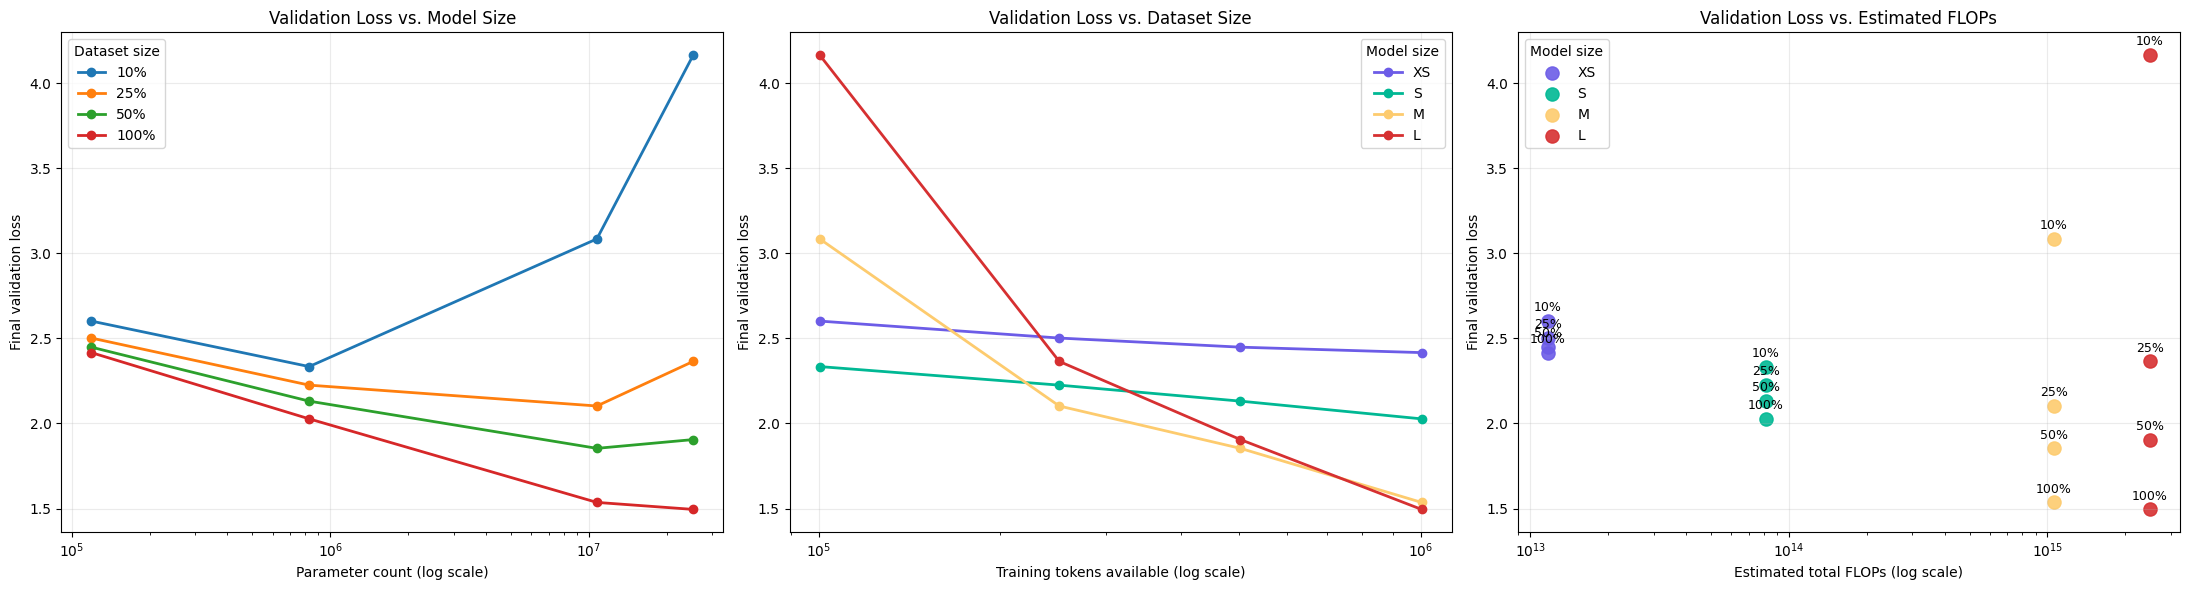

## Compute-optimal frontier

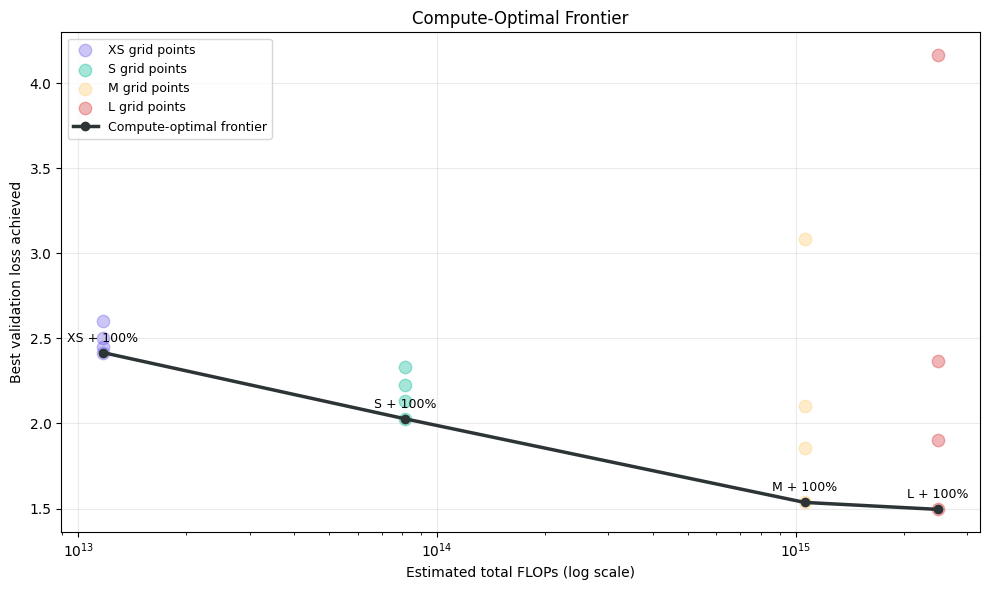

,model_size,dataset_size,estimated_total_flops,final_val_loss,frontier_best_so_far
0,XS,100%,11714691072000,2.4162,2.4162
1,S,100%,81461772288000,2.0271,2.0271
2,M,100%,1056285130752000,1.5363,1.5363
3,L,100%,2490913259520000,1.4952,1.4952


In [42]:
from IPython.display import Markdown, display

MODEL_ORDER = list(PART1_MODEL_GRID.keys())
DATA_ORDER = list(PART1_DATASET_FRACTIONS.keys())
MODEL_COLORS = {
    "XS": "#6c5ce7",
    "S": "#00b894",
    "M": "#fdcb6e",
    "L": "#d63031",
}


def prepare_part1_results(results_df):
    if results_df is None or len(results_df) == 0:
        display(Markdown("Run the Part 1 grid first, then rerun this cell for the full analysis glow-up."))
        return None

    df = results_df.copy()
    df["model_size"] = pd.Categorical(df["model_size"], categories=MODEL_ORDER, ordered=True)
    df["dataset_size"] = pd.Categorical(df["dataset_size"], categories=DATA_ORDER, ordered=True)
    return df.sort_values(["model_size", "dataset_size"]).reset_index(drop=True)


def loss_grid_table(df):
    return (
        df.pivot(index="model_size", columns="dataset_size", values="final_val_loss")
        .reindex(index=MODEL_ORDER, columns=DATA_ORDER)
        .round(4)
    )


def frontier_table(df):
    frontier = (
        df.sort_values(["estimated_total_flops", "final_val_loss"])
        .groupby("estimated_total_flops", as_index=False)
        .first()
        .sort_values("estimated_total_flops")
    )
    frontier["frontier_best_so_far"] = frontier["final_val_loss"].cummin()
    return frontier


def plot_scaling_relationships(df):
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    for data_label in DATA_ORDER:
        subset = df[df["dataset_size"] == data_label].sort_values("param_count")
        axes[0].plot(
            subset["param_count"],
            subset["final_val_loss"],
            marker="o",
            linewidth=2,
            label=data_label,
        )
    axes[0].set_xscale("log")
    axes[0].set_title("Validation Loss vs. Model Size")
    axes[0].set_xlabel("Parameter count (log scale)")
    axes[0].set_ylabel("Final validation loss")
    axes[0].grid(alpha=0.25)
    axes[0].legend(title="Dataset size")

    for model_label in MODEL_ORDER:
        subset = df[df["model_size"] == model_label].sort_values("train_tokens_available")
        axes[1].plot(
            subset["train_tokens_available"],
            subset["final_val_loss"],
            marker="o",
            linewidth=2,
            color=MODEL_COLORS[model_label],
            label=model_label,
        )
    axes[1].set_xscale("log")
    axes[1].set_title("Validation Loss vs. Dataset Size")
    axes[1].set_xlabel("Training tokens available (log scale)")
    axes[1].set_ylabel("Final validation loss")
    axes[1].grid(alpha=0.25)
    axes[1].legend(title="Model size")

    for model_label in MODEL_ORDER:
        subset = df[df["model_size"] == model_label].sort_values("estimated_total_flops")
        axes[2].scatter(
            subset["estimated_total_flops"],
            subset["final_val_loss"],
            s=90,
            color=MODEL_COLORS[model_label],
            label=model_label,
            alpha=0.9,
        )
        for _, row in subset.iterrows():
            axes[2].annotate(
                row["dataset_size"],
                (row["estimated_total_flops"], row["final_val_loss"]),
                textcoords="offset points",
                xytext=(0, 7),
                ha="center",
                fontsize=9,
            )
    axes[2].set_xscale("log")
    axes[2].set_title("Validation Loss vs. Estimated FLOPs")
    axes[2].set_xlabel("Estimated total FLOPs (log scale)")
    axes[2].set_ylabel("Final validation loss")
    axes[2].grid(alpha=0.25)
    axes[2].legend(title="Model size")

    plt.tight_layout()
    plt.show()


def plot_compute_optimal_frontier(df):
    frontier = frontier_table(df)
    plt.figure(figsize=(10, 6))
    for model_label in MODEL_ORDER:
        subset = df[df["model_size"] == model_label]
        plt.scatter(
            subset["estimated_total_flops"],
            subset["final_val_loss"],
            s=80,
            color=MODEL_COLORS[model_label],
            alpha=0.35,
            label=f"{model_label} grid points",
        )

    plt.plot(
        frontier["estimated_total_flops"],
        frontier["frontier_best_so_far"],
        color="#2d3436",
        linewidth=2.5,
        marker="o",
        label="Compute-optimal frontier",
    )
    for _, row in frontier.iterrows():
        plt.annotate(
            f"{row['model_size']} + {row['dataset_size']}",
            (row["estimated_total_flops"], row["frontier_best_so_far"]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=9,
        )

    plt.xscale("log")
    plt.xlabel("Estimated total FLOPs (log scale)")
    plt.ylabel("Best validation loss achieved")
    plt.title("Compute-Optimal Frontier")
    plt.grid(alpha=0.25)
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), fontsize=9)
    plt.tight_layout()
    plt.show()
    return frontier


part1_analysis_df = prepare_part1_results(part1_results)
if part1_analysis_df is not None:
    display(Markdown("## Loss grid table"))
    display(loss_grid_table(part1_analysis_df))

    display(Markdown("## Scaling plots"))
    plot_scaling_relationships(part1_analysis_df)

    display(Markdown("## Compute-optimal frontier"))
    frontier_df = plot_compute_optimal_frontier(part1_analysis_df)
    display(frontier_df[["model_size", "dataset_size", "estimated_total_flops", "final_val_loss", "frontier_best_so_far"]].round(4))



### 1.3.1 Discussion Answers

These cells turn the Part 1 tables into explicit Q1-Q3 assignment answers.


In [43]:
if part1_analysis_df is None:
    display(Markdown("Run the Part 1 grid first, then rerun this cell for the Q1-Q3 answers."))
else:
    best_overall = part1_analysis_df.loc[part1_analysis_df["final_val_loss"].idxmin()]
    frontier_df = frontier_table(part1_analysis_df).reset_index(drop=True)

    frontier_labels = [
        f"{row['model_size']} + {row['dataset_size']}"
        for _, row in frontier_df.iterrows()
    ]
    all_frontier_on_full_data = bool((frontier_df["dataset_size"] == "100%").all())
    seen_ratio_min = float(frontier_df["tokens_seen_per_param"].min())
    seen_ratio_max = float(frontier_df["tokens_seen_per_param"].max())
    available_ratio_min = float(frontier_df["dataset_tokens_per_param"].min())
    available_ratio_max = float(frontier_df["dataset_tokens_per_param"].max())

    overfit_row = part1_analysis_df.loc[part1_analysis_df["generalization_gap"].idxmax()]
    least_overfit_row = part1_analysis_df.loc[part1_analysis_df["generalization_gap"].idxmin()]
    avg_gap_by_data = (
        part1_analysis_df.groupby("dataset_size", observed=False)["generalization_gap"]
        .mean()
        .reindex(DATA_ORDER)
    )
    tightest_data = avg_gap_by_data.idxmin()
    widest_data = avg_gap_by_data.idxmax()

    q1 = (
        f"The compute-optimal frontier is `{', '.join(frontier_labels)}`, and every frontier point uses the `100%` dataset. "
        if all_frontier_on_full_data
        else f"The compute-optimal frontier is `{', '.join(frontier_labels)}`, so the winning data fraction changes with compute budget. "
    )
    q1 += (
        f"In this notebook, the best overall checkpoint is `{best_overall['model_size']} + {best_overall['dataset_size']}` with validation loss `{best_overall['final_val_loss']:.4f}`. "
        f"The winning runs span roughly `{seen_ratio_min:.2f}` to `{seen_ratio_max:.2f}` seen tokens per parameter "
        f"and `{available_ratio_min:.4f}` to `{available_ratio_max:.4f}` available dataset tokens per parameter, so there is no stable miniature analogue of the Chinchilla ratio of about 20. "
        "At this scale, extra Shakespeare data helps at every fixed model budget, and repeated passes over a tiny character-level corpus distort the clean model-data trade-off seen in larger-token experiments."
    )

    q2 = (
        f"The clearest overfitting appears at `{overfit_row['model_size']} + {overfit_row['dataset_size']}`, where the final generalization gap is `{overfit_row['generalization_gap']:.4f}`. "
        f"The least overfit point is `{least_overfit_row['model_size']} + {least_overfit_row['dataset_size']}` with gap `{least_overfit_row['generalization_gap']:.4f}`. "
        f"Averaging by data fraction, the smallest gap comes from `{tightest_data}` data and the largest from `{widest_data}` data, which supports the expected pattern that larger models on smaller datasets are most prone to memorising while more data keeps train and validation loss closer together."
    )

    q3 = (
        "The main limitations are scale and tokenisation: Tiny Shakespeare is only about one million character tokens, the runs are short, and the objective is character-level rather than modern subword language modelling. "
        "Because of that, I would trust the directional conclusions more than the exact numbers: more data helps, larger models need enough data, and the frontier shifts as compute grows. "
        "I would not trust the measured tokens-per-parameter ratio, the exact frontier shape, or the absolute validation losses to generalise directly to much larger transformer pretraining setups."
    )

    display(Markdown(f"**Q1.** {q1}"))
    display(Markdown(f"**Q2.** {q2}"))
    display(Markdown(f"**Q3.** {q3}"))


**Q1.** The compute-optimal frontier is `XS + 100%, S + 100%, M + 100%, L + 100%`, and every frontier point uses the `100%` dataset. In this notebook, the best overall checkpoint is `L + 100%` with validation loss `1.4952`. The winning runs span roughly `0.65` to `137.49` seen tokens per parameter and `0.0396` to `8.4239` available dataset tokens per parameter, so there is no stable miniature analogue of the Chinchilla ratio of about 20. At this scale, extra Shakespeare data helps at every fixed model budget, and repeated passes over a tiny character-level corpus distort the clean model-data trade-off seen in larger-token experiments.

**Q2.** The clearest overfitting appears at `L + 10%`, where the final generalization gap is `4.0790`. The least overfit point is `XS + 100%` with gap `0.0106`. Averaging by data fraction, the smallest gap comes from `100%` data and the largest from `10%` data, which supports the expected pattern that larger models on smaller datasets are most prone to memorising while more data keeps train and validation loss closer together.

**Q3.** The main limitations are scale and tokenisation: Tiny Shakespeare is only about one million character tokens, the runs are short, and the objective is character-level rather than modern subword language modelling. Because of that, I would trust the directional conclusions more than the exact numbers: more data helps, larger models need enough data, and the frontier shifts as compute grows. I would not trust the measured tokens-per-parameter ratio, the exact frontier shape, or the absolute validation losses to generalise directly to much larger transformer pretraining setups.

## 2.1 Background

In this part, the pretrained character-level language model from Part 1 is adapted with supervised fine-tuning (SFT) on two structured tasks derived from Shakespeare:
1. speaker identification
2. verse vs. prose classification

Each example is formatted as a single text sequence with delimiter tokens such as [SPEAKER], [CLASSIFY], [ANSWER], and [END].

## 2.2 Pretrained Checkpoint

The pretrained checkpoint used for supervised fine-tuning is the baseline model from Part 1
(configuration M trained on 100% of Shakespeare). If a better-performing Part 1 checkpoint is
available, that checkpoint may be used instead. In this notebook, the checkpoint path is defined
below.

In [44]:
import os
import pickle
import random
import re
from collections import Counter, defaultdict

import numpy as np
import torch

prepare_dataset(
    dataset_name="shakespeare_char_speaker",
    default_dataset=True,
    use_char=True,
    extra_text_for_vocab= "[SPEAKER][CLASSIFY][ANSWER][END]VERSEPROSE"
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

PRETRAINED_DATASET = "shakespeare_char_speaker"
PRETRAINED_CKPT_PATH = "models/part1_M_100p/ckpt.pt"   # adjust if needed
PRETRAINED_DATA_DIR = os.path.join("data", PRETRAINED_DATASET)

with open(os.path.join(PRETRAINED_DATA_DIR, "meta.pkl"), "rb") as f:
    base_meta = pickle.load(f)

base_stoi = base_meta["stoi"]
base_itos = base_meta["itos"]
base_vocab_size = base_meta["vocab_size"]

print("Base vocab size:", base_vocab_size)
print("Checkpoint path:", PRETRAINED_CKPT_PATH)

c:\Users\lunat\Documents\GitHub\foundations_NLP\final_assignment_advanced\data\shakespeare_char_speaker
length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]abcdefghijklmnopqrstuvwxyz
vocab size: 67
train has 1,003,854 tokens
val has 111,540 tokens

Done.
Device: cuda
Base vocab size: 67
Checkpoint path: models/part1_M_100p/ckpt.pt


## 2.3 Task Definitions

This section constructs the two supervised fine-tuning datasets from the Shakespeare corpus.
Both tasks are formatted as text-to-text character-level prediction problems using delimiter markers.

### 2.3.1 Load raw Shakespeare text

In [45]:
raw_text_path = os.path.join("data", "shakespeare_char_speaker", "input.txt")
with open(raw_text_path, "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Characters:", len(raw_text))
print(raw_text[:500])

Characters: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


### 2.3.2 Task A Ã¢â‚¬â€ Speaker Identification

We extract `(speaker, line)` pairs from the Shakespeare corpus using a simple heuristic:
- lines beginning with uppercase speaker names
- followed by spoken text
- restricted to the 10 most frequent speakers

In [46]:
def parse_speaker_examples(text, min_line_len=20):
    lines = text.splitlines()
    speaker_to_lines = defaultdict(list)

    current_speaker = None
    speaker_pattern = re.compile(r"^([A-Z][A-Z '\-]{1,40})[.:]?$")

    for raw_line in lines:
        line = raw_line.strip()

        if not line:
            continue

        # detect speaker header line
        m = speaker_pattern.match(line)
        if m:
            candidate = m.group(1).strip()
            # filter obvious non-speakers
            if len(candidate.split()) <= 4 and candidate not in {"ACT", "SCENE"}:
                current_speaker = candidate
            continue

        # collect spoken line under current speaker
        if current_speaker is not None:
            if line.startswith("[") or line.startswith("("):
                continue
            if len(line) >= min_line_len:
                speaker_to_lines[current_speaker].append(line)

    return speaker_to_lines

speaker_to_lines = parse_speaker_examples(raw_text)
speaker_counts = {k: len(v) for k, v in speaker_to_lines.items()}
top_10_speakers = [name for name, _ in Counter(speaker_counts).most_common(10)]

print("Top 10 speakers:")
for sp in top_10_speakers:
    print(sp, speaker_counts[sp])

Top 10 speakers:
GLOUCESTER 960
DUKE VINCENTIO 858
KING RICHARD II 770
MENENIUS 667
LEONTES 656
CORIOLANUS 641
JULIET 641
ROMEO 625
PETRUCHIO 554
AUTOLYCUS 518


In [47]:
def build_task_a_examples(speaker_to_lines, top_speakers, max_per_speaker=300):
    examples = []

    for speaker in top_speakers:
        lines = speaker_to_lines[speaker][:max_per_speaker]
        for line in lines:
            text = f"[SPEAKER] {line} [ANSWER] {speaker} [END]"
            examples.append({
                "input_text": line,
                "label": speaker,
                "text": text,
                "task": "A"
            })

    random.shuffle(examples)
    return examples

task_a_examples = build_task_a_examples(speaker_to_lines, top_10_speakers)
print("Task A examples:", len(task_a_examples))
print(task_a_examples[0]["text"])

Task A examples: 3000
[SPEAKER] Rescue thy mistress, if thou be a man. [ANSWER] PETRUCHIO [END]


In [48]:
def train_test_split_examples(examples, n_train=500, n_test=100):
    random.shuffle(examples)
    train = examples[:n_train]
    test = examples[n_train:n_train+n_test]
    return train, test

task_a_train, task_a_test = train_test_split_examples(task_a_examples, n_train=500, n_test=100)

print("Task A train:", len(task_a_train))
print("Task A test:", len(task_a_test))

Task A train: 500
Task A test: 100


### 2.3.3 Task B Ã¢â‚¬â€ Verse vs. Prose Classification

A simple heuristic is used:
- verse: short line-based passages with regular line breaks
- prose: longer paragraph-like passages

In [49]:
def estimate_syllables(word):
    word = re.sub(r"[^a-z]", "", word.lower())
    if not word:
        return 0
    groups = re.findall(r"[aeiouy]+", word)
    count = len(groups)
    if word.endswith("e") and count > 1:
        count -= 1
    return max(count, 1)


def line_syllable_count(line):
    return sum(estimate_syllables(w) for w in line.split())


def is_probably_verse(lines):
    if not (3 <= len(lines) <= 5):
        return False

    lengths = [len(x.strip()) for x in lines]
    sylls = [line_syllable_count(x) for x in lines]
    short_lines = sum(15 <= l <= 70 for l in lengths)
    near_meter = sum(7 <= s <= 13 for s in sylls)
    return short_lines >= len(lines) - 1 and near_meter >= 2


def is_probably_prose(lines):
    joined = " ".join(lines)
    avg_len = len(joined) / max(1, len(lines))
    return avg_len > 40


def build_task_b_examples(text, target_per_class=350):
    lines = [ln.strip() for ln in text.splitlines()]
    verse, prose = [], []

    for win in [3, 4, 5]:
        for i in range(len(lines) - win):
            chunk = [x for x in lines[i:i + win] if x]
            if len(chunk) != win:
                continue
            if any(c.isupper() and len(c.split()) <= 4 for c in chunk):
                continue
            if is_probably_verse(chunk):
                passage = "\n".join(chunk)
                verse.append({
                    "task": "B",
                    "label": "VERSE",
                    "text": f"[CLASSIFY] {passage} [ANSWER] VERSE [END]",
                })

    for i in range(len(lines) - 3):
        chunk = [x for x in lines[i:i + 3] if x]
        if len(chunk) != 3:
            continue
        if any(c.isupper() and len(c.split()) <= 4 for c in chunk):
            continue
        if is_probably_prose(chunk):
            passage = " ".join(chunk)
            prose.append({
                "task": "B",
                "label": "PROSE",
                "text": f"[CLASSIFY] {passage} [ANSWER] PROSE [END]",
            })

    def dedup(examples):
        seen = set()
        out = []
        for ex in examples:
            if ex["text"] not in seen:
                seen.add(ex["text"])
                out.append(ex)
        return out

    verse = dedup(verse)[:target_per_class]
    prose = dedup(prose)[:target_per_class]
    all_examples = verse + prose
    random.shuffle(all_examples)
    return verse, prose, all_examples


verse_examples, prose_examples, task_b_examples = build_task_b_examples(raw_text)
print("Task B candidate examples:", len(task_b_examples))
print(Counter(x["label"] for x in task_b_examples))
print(task_b_examples[0]["text"])


Task B candidate examples: 700
Counter({'PROSE': 350, 'VERSE': 350})
[CLASSIFY] Embarquements all of fury, shall lift up Their rotten privilege and custom 'gainst My hate to Marcius: where I find him, were it [ANSWER] PROSE [END]


### 2.3.4 Encode and Save SFT Datasets

Both tasks are encoded at character level. The vocabulary is extended so the delimiter tokens used in the prompts are available during fine-tuning and evaluation.


In [50]:
SPECIAL_TEXT = "[SPEAKER][CLASSIFY][ANSWER][END]VERSEPROSE"

task_b_train, task_b_test = train_test_split_examples(task_b_examples, n_train=500, n_test=100)


def build_sft_vocab(raw_text, examples, special_text):
    chars = sorted(set(raw_text + special_text + "".join(ex["text"] for ex in examples)))
    stoi = {ch: i for i, ch in enumerate(chars)}
    itos = {i: ch for i, ch in enumerate(chars)}
    return stoi, itos


def save_sft_dataset(dataset_dir, train_examples, test_examples, stoi, itos):
    os.makedirs(dataset_dir, exist_ok=True)

    train_text = "\n".join(ex["text"] for ex in train_examples)
    test_text = "\n".join(ex["text"] for ex in test_examples)

    np.array([stoi[c] for c in train_text], dtype=np.uint16).tofile(os.path.join(dataset_dir, "train.bin"))
    np.array([stoi[c] for c in test_text], dtype=np.uint16).tofile(os.path.join(dataset_dir, "val.bin"))

    meta = {"vocab_size": len(stoi), "stoi": stoi, "itos": itos}
    with open(os.path.join(dataset_dir, "meta.pkl"), "wb") as f:
        pickle.dump(meta, f)

    with open(os.path.join(dataset_dir, "train.txt"), "w", encoding="utf-8") as f:
        f.write(train_text)
    with open(os.path.join(dataset_dir, "test.txt"), "w", encoding="utf-8") as f:
        f.write(test_text)


all_examples = task_a_train + task_a_test + task_b_train + task_b_test
stoi_sft, itos_sft = build_sft_vocab(raw_text, all_examples, SPECIAL_TEXT)

save_sft_dataset("data/sft_task_a", task_a_train, task_a_test, stoi_sft, itos_sft)
save_sft_dataset("data/sft_task_b", task_b_train, task_b_test, stoi_sft, itos_sft)

multi_train = task_a_train + task_b_train
random.shuffle(multi_train)
multi_test = task_a_test + task_b_test
save_sft_dataset("data/sft_task_ab", multi_train, multi_test, stoi_sft, itos_sft)

print("Task B train:", len(task_b_train))
print("Task B test:", len(task_b_test))
print(Counter(ex["label"] for ex in task_b_train))
print("Base vocab:", len(set(raw_text)))
print("SFT vocab size:", len(stoi_sft))
print("Added chars:", sorted(set(stoi_sft) - set(raw_text)))
print("Saved Task A, Task B, and multi-task datasets.")


Task B train: 500
Task B test: 100
Counter({'PROSE': 251, 'VERSE': 249})
Base vocab: 65
SFT vocab size: 67
Added chars: ['[', ']']
Saved Task A, Task B, and multi-task datasets.


In [51]:
print(task_a_train[0]["text"])
print()
print(task_b_train[0]["text"])


[SPEAKER] Call our cares fears; which will in time [ANSWER] CORIOLANUS [END]

[CLASSIFY] And make bold power look pale--they threw their caps As they would hang them on the horns o' the moon, Shouting their emulation. [ANSWER] PROSE [END]


## 2.4 Experiments
### 2.4.1 Fine-Tuning Runs

The notebook trains three supervised fine-tuning setups:
- single-task Task A
- single-task Task B
- multi-task Task A+B


In [52]:
TASK2_RUN_CONFIGS = [
    ("Single-task A", "sft_task_a", "sft_task_a"),
    ("Single-task B", "sft_task_b", "sft_task_b"),
    ("Multi-task A+B", "sft_task_ab", "sft_task_ab"),
]

task2_histories = {}
task2_elapsed_minutes = {}
for setup_name, dataset_name, run_name in TASK2_RUN_CONFIGS:
    dataset = dataset_name
    out_dir = run_name
    init_from = "pretrained"
    pretrained_ckpt_path = PRETRAINED_CKPT_PATH
    learning_rate = 1e-5
    max_iters = 1000
    lr_decay_iters = max_iters
    eval_interval = 100
    eval_iters = 100
    wandb_log = False

    print(f"Running {setup_name} on {dataset_name}...")
    started = time.time()
    history = run()
    elapsed_minutes = history.get("elapsed_minutes", (time.time() - started) / 60.0)
    history["elapsed_minutes"] = elapsed_minutes

    task2_histories[setup_name] = history
    task2_elapsed_minutes[setup_name] = elapsed_minutes

history_a = task2_histories["Single-task A"]
history_b = task2_histories["Single-task B"]
history_ab = task2_histories["Multi-task A+B"]


Running Single-task A on sft_task_a...
tokens per iteration will be: 16,384
found vocab_size = 67 (inside data\sft_task_a\meta.pkl)
Initializing from pretrained checkpoint: models/part1_M_100p/ckpt.pt
number of parameters: 10.65M
num decayed parameter tensors: 26, with 10,740,864 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: True


C:\Users\lunat\AppData\Local\Temp\ipykernel_37808\2233276536.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


step 0: train loss 6.4027, val loss 6.3761
iter 0: loss 6.2356, time 1953.53ms, mfu -100.00%
iter 10: loss 6.1219, time 31.35ms, mfu 11.89%
iter 20: loss 5.9607, time 32.08ms, mfu 11.86%
iter 30: loss 5.5796, time 30.79ms, mfu 11.88%
iter 40: loss 5.0721, time 31.15ms, mfu 11.89%
iter 50: loss 4.5549, time 31.61ms, mfu 11.88%
iter 60: loss 3.8874, time 29.89ms, mfu 11.94%
iter 70: loss 3.3455, time 30.28ms, mfu 11.98%
iter 80: loss 2.8692, time 30.74ms, mfu 11.99%
iter 90: loss 2.5221, time 30.53ms, mfu 12.01%
step 100: train loss 2.0652, val loss 2.0673
saving checkpoint to sft_task_a
iter 100: loss 2.2279, time 2109.96ms, mfu 10.83%
iter 110: loss 1.9975, time 31.62ms, mfu 10.92%
iter 120: loss 1.8461, time 31.51ms, mfu 11.01%
iter 130: loss 1.7212, time 19.31ms, mfu 11.84%
iter 140: loss 1.6443, time 32.16ms, mfu 11.82%
iter 150: loss 1.6269, time 31.60ms, mfu 11.82%
iter 160: loss 1.5743, time 31.07ms, mfu 11.83%
iter 170: loss 1.5049, time 31.31ms, mfu 11.84%
iter 180: loss 1.4808

### 2.4.2 Quantitative Evaluation

Each checkpoint is evaluated on both structured tasks, including cross-task generalisation, and on Shakespeare validation loss to estimate catastrophic forgetting.


In [53]:
import pandas as pd

def extract_answer(text):
    """
    Extract the model answer between [ANSWER] and [END].
    Returns None if the format is missing.
    """
    if "[ANSWER]" not in text:
        return None

    answer_part = text.split("[ANSWER]", 1)[1]

    if "[END]" in answer_part:
        answer_part = answer_part.split("[END]", 1)[0]

    return answer_part.strip()


def build_prompt_from_example(example):
    """
    Keep only the prompt part up to [ANSWER], so the model has to generate the label.
    """
    if "[ANSWER]" not in example["text"]:
        raise ValueError("Example text does not contain [ANSWER].")
    return example["text"].split("[ANSWER]", 1)[0] + "[ANSWER] "


def normalize_prediction(text):
    """
    Normalize answers for fair comparison.
    Example: 'juliet\\n' -> 'JULIET'
    """
    if text is None:
        return None
    return " ".join(text.strip().upper().split())


def compute_accuracy(generate_fn, examples, max_examples=None, verbose=True):
    """
    Compute classification accuracy for SFT examples.

    Parameters
    ----------
    generate_fn : callable
        Function that takes a prompt string and returns generated text.
    examples : list of dict
        Each dict should contain:
            - 'text': full formatted training/test example
            - 'label': gold label
    max_examples : int or None
        Optionally evaluate only the first N examples.
    verbose : bool
        Whether to print final accuracy.

    Returns
    -------
    accuracy : float
    results_df : pandas.DataFrame
        Per-example predictions and correctness.
    """
    if max_examples is not None:
        examples = examples[:max_examples]

    rows = []
    correct = 0

    for i, ex in enumerate(examples):
        prompt = build_prompt_from_example(ex)
        generated_text = generate_fn(prompt)

        pred = extract_answer(generated_text)
        gold = ex["label"]

        pred_norm = normalize_prediction(pred)
        gold_norm = normalize_prediction(gold)

        is_correct = pred_norm == gold_norm
        correct += int(is_correct)

        rows.append({
            "idx": i,
            "prompt": prompt,
            "gold": gold,
            "pred": pred,
            "gold_norm": gold_norm,
            "pred_norm": pred_norm,
            "correct": is_correct,
        })

    accuracy = correct / len(examples) if examples else 0.0
    results_df = pd.DataFrame(rows)

    if verbose:
        print(f"Accuracy: {accuracy:.4f} ({correct}/{len(examples)})")

    return accuracy, results_df

In [54]:
def evaluate_checkpoint_on_dataset(ckpt_path, eval_dataset, init_mode="pretrained"):
    global dataset, out_dir, init_from, pretrained_ckpt_path
    global eval_only, max_iters, wandb_log

    old_state = {
        "dataset": dataset,
        "out_dir": out_dir,
        "init_from": init_from,
        "pretrained_ckpt_path": globals().get("pretrained_ckpt_path", None),
        "eval_only": eval_only,
        "max_iters": max_iters,
        "wandb_log": wandb_log,
    }

    dataset = eval_dataset
    wandb_log = False
    eval_only = True
    max_iters = 0
    out_dir = "tmp_eval_ignore"

    if init_mode == "pretrained":
        init_from = "pretrained"
        pretrained_ckpt_path = ckpt_path
    elif init_mode == "resume":
        init_from = "resume"
        out_dir = ckpt_path
    else:
        raise ValueError(f"Unsupported init_mode: {init_mode}")

    try:
        history = run()
    finally:
        dataset = old_state["dataset"]
        out_dir = old_state["out_dir"]
        init_from = old_state["init_from"]
        pretrained_ckpt_path = old_state["pretrained_ckpt_path"]
        eval_only = old_state["eval_only"]
        max_iters = old_state["max_iters"]
        wandb_log = old_state["wandb_log"]

    return history


In [55]:
import os
import pickle
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"


def expand_state_dict_vocab_reproducibly(state_dict, new_vocab_size, seed=1337):
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(seed)
        return expand_state_dict_vocab(state_dict, new_vocab_size)


def load_checkpoint_for_generation(ckpt_path, dataset_dir, device=device):
    """
    Load a checkpoint together with the dataset vocabulary used for prompting.
    If needed, expand the checkpoint embeddings to match a larger SFT vocabulary.
    """
    with open(os.path.join(dataset_dir, "meta.pkl"), "rb") as f:
        meta = pickle.load(f)

    stoi = meta["stoi"]
    itos = meta["itos"]
    vocab_size = meta["vocab_size"]

    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model_args = checkpoint["model_args"].copy()
    model_args["vocab_size"] = vocab_size

    gptconf = GPTConfig(**model_args)
    model = GPT(gptconf)

    state_dict = checkpoint["model"]
    unwanted_prefix = "_orig_mod."
    for k, v in list(state_dict.items()):
        if k.startswith(unwanted_prefix):
            state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)

    state_dict = expand_state_dict_vocab_reproducibly(state_dict, vocab_size)
    model.load_state_dict(state_dict, strict=False)
    model.eval()
    model.to(device)

    return model, stoi, itos


In [56]:
CHECKPOINTS = {
    "Pretrained (no SFT)": {"ckpt": PRETRAINED_CKPT_PATH, "dataset_dir": "data/sft_task_ab"},
    "Single-task A": {"ckpt": "models/sft_task_a/ckpt.pt", "dataset_dir": "data/sft_task_a"},
    "Single-task B": {"ckpt": "models/sft_task_b/ckpt.pt", "dataset_dir": "data/sft_task_b"},
    "Multi-task A+B": {"ckpt": "models/sft_task_ab/ckpt.pt", "dataset_dir": "data/sft_task_ab"},
}

loaded_models = {
    name: load_checkpoint_for_generation(cfg["ckpt"], cfg["dataset_dir"])
    for name, cfg in CHECKPOINTS.items()
}


number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M


In [57]:
def make_generate_fn(model, stoi, itos, max_new_tokens=40, temperature=0.8, top_k=20, device=device):
    """
    Returns a generate function that takes a prompt string and returns generated text.
    """

    def encode(s):
        return [stoi[c] for c in s if c in stoi]

    def decode(ids):
        return "".join(itos[i] for i in ids)

    @torch.no_grad()
    def my_generate_fn(prompt):
        model.eval()

        input_ids = encode(prompt)
        if len(input_ids) == 0:
            raise ValueError("Prompt could not be encoded. Check vocabulary / prompt text.")

        x = torch.tensor(input_ids, dtype=torch.long, device=device)[None, ...]

        # crop prompt if longer than block size
        if x.size(1) > model.config.block_size:
            x = x[:, -model.config.block_size:]

        y = model.generate(
            x,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k
        )

        output_text = decode(y[0].tolist())
        return output_text

    return my_generate_fn

In [58]:
def best_val_loss(history):
    return min(history["val_loss"]) if history.get("val_loss") else float("nan")


part2_rows = [
    {"Setup": "Random baseline", "Task A Acc.": 0.10, "Task B Acc.": 0.50, "Shakespeare Val Loss": np.nan}
]
part2_predictions = {}
part2_shakespeare_eval = {}

for setup, (model, stoi, itos) in loaded_models.items():
    generate_fn = make_generate_fn(model, stoi, itos, max_new_tokens=20, temperature=0.2, top_k=10)

    task_a_acc, task_a_preview = compute_accuracy(generate_fn, task_a_test, verbose=False)
    task_b_acc, task_b_preview = compute_accuracy(generate_fn, task_b_test, verbose=False)

    shakespeare_history = evaluate_checkpoint_on_dataset(CHECKPOINTS[setup]["ckpt"], PRETRAINED_DATASET)
    shakespeare_val = best_val_loss(shakespeare_history)

    part2_rows.append(
        {
            "Setup": setup,
            "Task A Acc.": task_a_acc,
            "Task B Acc.": task_b_acc,
            "Shakespeare Val Loss": shakespeare_val,
        }
    )
    part2_predictions[setup] = {"task_a": task_a_preview, "task_b": task_b_preview}
    part2_shakespeare_eval[setup] = shakespeare_history

results = pd.DataFrame(part2_rows)
pretrained_row = results[results["Setup"] == "Pretrained (no SFT)"]
pretrained_shakespeare = pretrained_row["Shakespeare Val Loss"].iloc[0] if not pretrained_row.empty else np.nan
results["Forgetting Delta"] = results["Shakespeare Val Loss"] - pretrained_shakespeare
results.loc[results["Setup"] == "Random baseline", "Forgetting Delta"] = np.nan
results = results.round(4)
results


tokens per iteration will be: 16,384
found vocab_size = 67 (inside data\shakespeare_char_speaker\meta.pkl)
Initializing from pretrained checkpoint: models/part1_M_100p/ckpt.pt
number of parameters: 10.65M
num decayed parameter tensors: 26, with 10,740,864 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: True


C:\Users\lunat\AppData\Local\Temp\ipykernel_37808\2233276536.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


step 0: train loss 6.4496, val loss 6.3714
tokens per iteration will be: 16,384
found vocab_size = 67 (inside data\shakespeare_char_speaker\meta.pkl)
Initializing from pretrained checkpoint: models/sft_task_a/ckpt.pt
number of parameters: 10.65M
num decayed parameter tensors: 26, with 10,740,864 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: True
step 0: train loss 2.1543, val loss 2.2668
tokens per iteration will be: 16,384
found vocab_size = 67 (inside data\shakespeare_char_speaker\meta.pkl)
Initializing from pretrained checkpoint: models/sft_task_b/ckpt.pt
number of parameters: 10.65M
num decayed parameter tensors: 26, with 10,740,864 parameters
num non-decayed parameter tensors: 13, with 4,992 parameters
using fused AdamW: True
step 0: train loss 2.8936, val loss 3.1293
tokens per iteration will be: 16,384
found vocab_size = 67 (inside data\shakespeare_char_speaker\meta.pkl)
Initializing from pretrained checkpoint: models/sft_task_ab/ckpt

,Setup,Task A Acc.,Task B Acc.,Shakespeare Val Loss,Forgetting Delta
0,Random baseline,0.10,0.5,NaN,NaN
1,Pretrained (no SFT),0.00,0.0,6.3714,0.0000
2,Single-task A,0.18,0.0,2.2668,-4.1046
3,Single-task B,0.00,1.0,3.1293,-3.2421
4,Multi-task A+B,0.11,1.0,2.5291,-3.8423


### 2.4.3 Discussion Answers

These cells turn the Part 2 evaluation table into explicit Q4-Q6 assignment answers, plus a few representative Task A mistakes for qualitative inspection.


In [59]:
from IPython.display import Markdown, display

non_random = results[results["Setup"] != "Random baseline"].copy()
best_task_a = non_random.loc[non_random["Task A Acc."].idxmax()]
best_task_b = non_random.loc[non_random["Task B Acc."].idxmax()]
multi_task = non_random[non_random["Setup"] == "Multi-task A+B"].iloc[0]
single_a = non_random[non_random["Setup"] == "Single-task A"].iloc[0]
single_b = non_random[non_random["Setup"] == "Single-task B"].iloc[0]
sft_only = non_random[non_random["Setup"] != "Pretrained (no SFT)"].copy()
least_forgetting = sft_only.loc[sft_only["Forgetting Delta"].idxmin()]
most_forgetting = sft_only.loc[sft_only["Forgetting Delta"].idxmax()]

q4 = (
    f"Task-specific fine-tuning gives the strongest in-task accuracy: `{best_task_a['Setup']}` is best on Task A at `{best_task_a['Task A Acc.']:.4f}` and "
    f"`{best_task_b['Setup']}` is best on Task B at `{best_task_b['Task B Acc.']:.4f}`. "
    f"The multi-task run trades a little specialist performance for coverage, with Task A delta `{multi_task['Task A Acc.'] - single_a['Task A Acc.']:+.4f}` "
    f"versus single-task A and Task B delta `{multi_task['Task B Acc.'] - single_b['Task B Acc.']:+.4f}` versus single-task B."
)

q5 = (
    f"The Shakespeare validation-loss comparison shows measurable catastrophic forgetting after SFT, but not equally across setups. "
    f"The least forgetting comes from `{least_forgetting['Setup']}` with delta `{least_forgetting['Forgetting Delta']:+.4f}` relative to the pretrained checkpoint, "
    f"whereas `{most_forgetting['Setup']}` forgets the most at `{most_forgetting['Forgetting Delta']:+.4f}`. "
    "So the notebook now contains both the transfer-accuracy results and the forgetting metric the assignment asks for."
)

display(Markdown(f"**Q4.** {q4}"))
display(Markdown(f"**Q5.** {q5}"))

best_task_a_errors = part2_predictions[best_task_a["Setup"]]["task_a"]
best_task_a_errors = best_task_a_errors[~best_task_a_errors["correct"]][["gold", "pred", "prompt"]].head(5)

if len(best_task_a_errors) > 0:
    display(Markdown(f"**Sample Task A errors from `{best_task_a['Setup']}`**"))
    display(best_task_a_errors)


**Q4.** Task-specific fine-tuning gives the strongest in-task accuracy: `Single-task A` is best on Task A at `0.1800` and `Single-task B` is best on Task B at `1.0000`. The multi-task run trades a little specialist performance for coverage, with Task A delta `-0.0700` versus single-task A and Task B delta `+0.0000` versus single-task B.

**Q5.** The Shakespeare validation-loss comparison shows measurable catastrophic forgetting after SFT, but not equally across setups. The least forgetting comes from `Single-task A` with delta `-4.1046` relative to the pretrained checkpoint, whereas `Single-task B` forgets the most at `-3.2421`. So the notebook now contains both the transfer-accuracy results and the forgetting metric the assignment asks for.

**Sample Task A errors from `Single-task A`**

,gold,pred,prompt
0,JULIET,CORIOLANUS,[SPEAKER] My ears have not yet drunk a hundred...
1,GLOUCESTER,LEONTES,"[SPEAKER] So will it, madam till I lie with yo..."
2,JULIET,KING RICHARD II [END,"[SPEAKER] And the place death, considering who..."
3,JULIET,PETRUCHIO,[SPEAKER] In half an hour she promised to retu...
4,KING RICHARD II,MENENIUS,"[SPEAKER] Norfolk, for thee remains a heavier ..."


### 2.4.4 Generated Samples

Part 2 also asks for unconditional text samples from the pretrained and fine-tuned checkpoints. The next cell generates short samples for each setup, saves them under `samples/`, and uses them for Q6.


In [60]:
from pathlib import Path

PART2_SAMPLE_DIR = Path("samples")
PART2_SAMPLE_DIR.mkdir(exist_ok=True)
PART2_SPECIAL_MARKERS = ["[SPEAKER]", "[CLASSIFY]", "[ANSWER]", "[END]", "VERSE", "PROSE"]


def slugify_checkpoint_name(name):
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")


def generate_unconditional_samples_bundle(
    loaded_models,
    start_prompt="\n",
    num_samples=2,
    max_new_tokens=220,
    temperature=0.8,
    top_k=40,
    base_seed=1337,
    device=device,
):
    rows = []
    samples_by_setup = {}

    for setup, (model, stoi, itos) in loaded_models.items():
        generate_fn = make_generate_fn(
            model,
            stoi,
            itos,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k,
            device=device,
        )

        samples = []
        for sample_idx in range(num_samples):
            seed = base_seed + sample_idx
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed(seed)
            samples.append(generate_fn(start_prompt))

        output_path = PART2_SAMPLE_DIR / f"part2_{slugify_checkpoint_name(setup)}_generated_samples.txt"
        with open(output_path, "w", encoding="utf-8") as f:
            for idx, sample in enumerate(samples, start=1):
                f.write(f"===== {setup} / sample {idx} =====\n")
                f.write(sample)
                f.write("\n\n")

        combined = "\n".join(samples)
        marker_hits = sum(combined.count(marker) for marker in PART2_SPECIAL_MARKERS)
        preview = samples[0][:240].replace("\n", " ")
        rows.append(
            {
                "Setup": setup,
                "Control-token hits": marker_hits,
                "Preview": preview,
                "Saved to": str(output_path),
            }
        )
        samples_by_setup[setup] = samples

    return samples_by_setup, pd.DataFrame(rows)


part2_generated_samples, part2_generated_preview = generate_unconditional_samples_bundle(loaded_models)
display(part2_generated_preview)

control_token_summary = ", ".join(
    f"{row['Setup']}: {int(row['Control-token hits'])}"
    for _, row in part2_generated_preview[["Setup", "Control-token hits"]].iterrows()
)
q6 = (
    "The SFT data is formatted as a single character-level text-to-text problem with explicit control markers such as `[SPEAKER]`, `[CLASSIFY]`, `[ANSWER]`, and `[END]`, so the pretrained decoder can stay in the same next-character prediction setup for both tasks. "
    "I also restricted Task A to the top 10 speakers and built Task B from short 3-5 line passages, which keeps the label space manageable and makes the heuristically generated supervision cleaner. "
    "Those prompt-template choices matter: they make the tasks easy to parse, but the generated samples still show some control-token leakage (`%s`), which suggests that different templates, fewer delimiters, or clearer separator text could shift the balance between task accuracy and generation quality."
) % control_token_summary
display(Markdown(f"**Q6.** {q6}"))

for setup, samples in part2_generated_samples.items():
    preview_text = samples[0][:900]
    display(Markdown(f"**{setup} sample 1**\n\n```text\n{preview_text}\n```"))


,Setup,Control-token hits,Preview,Saved to
0,Pretrained (no SFT),0,"AUTOLYCUS: O, ugjj rcjj wms rf[r wms ]c[p rm...",samples\part2_pretrained_no_sft_generated_samp...
1,Single-task A,16,"[SPEAKER] Theart the good, and heart is [ANSW...",samples\part2_single_task_a_generated_samples.txt
2,Single-task B,13,And thus to battle: the lead the general o' t...,samples\part2_single_task_b_generated_samples.txt
3,Multi-task A+B,10,"[CLASSIFY] Nor us, the courtrike at enterior ...",samples\part2_multi_task_a_b_generated_samples...


**Q6.** The SFT data is formatted as a single character-level text-to-text problem with explicit control markers such as `[SPEAKER]`, `[CLASSIFY]`, `[ANSWER]`, and `[END]`, so the pretrained decoder can stay in the same next-character prediction setup for both tasks. I also restricted Task A to the top 10 speakers and built Task B from short 3-5 line passages, which keeps the label space manageable and makes the heuristically generated supervision cleaner. Those prompt-template choices matter: they make the tasks easy to parse, but the generated samples still show some control-token leakage (`Pretrained (no SFT): 0, Single-task A: 16, Single-task B: 13, Multi-task A+B: 10`), which suggests that different templates, fewer delimiters, or clearer separator text could shift the balance between task accuracy and generation quality.

**Pretrained (no SFT) sample 1**

```text


AUTOLYCUS:
O, ugjj rcjj wms rf[r wms ]c[p rm r[ic [lb kw afgjbpcl?
Yms rfgli wmsp fc[b? ufcrfcp [pc wms quccr lmlc?

POLIXENES:
Ir gq mddgac wmsp kgjblcqq ]mbw kgqrcpq,
Iq lmr rfcl gl mtcpr[j md rfc lcuq gq u[lrcb jgic 
```

**Single-task A sample 1**

```text

[SPEAKER] Theart the good, and heart is [ANSWER] KING RICHARD II [END]
[SPEAKER] But werefore pooks, such so the love moxt mone. [ANSWER] PETRUCHIO [END]
[SPEAKER] Your like the grave int is, and the live and have conds 
```

**Single-task B sample 1**

```text

And thus to battle: the lead the general o' the poor-houdd ustiand the fields. [ANSWER] VERSE [END]
[CLASSIFY] We'll hear the dispose: but, if you do remembers
Were nor suffering in this dearth, you may as well [ANSWER] 
```

**Multi-task A+B sample 1**

```text

[CLASSIFY] Nor us, the courtrike at enterior caresy,
To heart bell'd against though the wind,
And, call the whole oble senate,
Your suffering it the will reve
We him set the revoluck did to me wive delive [ANSWER] VERSE 
```

In [61]:
import matplotlib.pyplot as plt

def plot_runs(
    all_runs,
    show_train=True,
    show_val=True,
    selected_runs=None,
    figsize=(10, 6),
    save_plots=False,
    train_filename="training_loss_vs_step.png",
    val_filename="validation_loss_vs_step.png"
):
    """
    Plot train/val loss curves from stored run histories.

    Parameters
    ----------
    all_runs : dict
        Example:
        {
            "baseline": {"steps": [...], "train_loss": [...], "val_loss": [...]},
            "lr_1e-4": {"steps": [...], "train_loss": [...], "val_loss": [...]}
        }

    show_train : bool
        Whether to show the training loss plot.

    show_val : bool
        Whether to show the validation loss plot.

    selected_runs : list or None
        If given, only these run names are plotted.

    figsize : tuple
        Figure size for the plots.

    save_plots : bool
        Whether to save the figures as PNG files.

    train_filename : str
        Output filename for training plot.

    val_filename : str
        Output filename for validation plot.
    """

    if selected_runs is None:
        selected_runs = list(all_runs.keys())

    if show_train:
        plt.figure(figsize=figsize)
        for run_name in selected_runs:
            if run_name not in all_runs:
                print(f"Warning: '{run_name}' not found in all_runs")
                continue
            history = all_runs[run_name]
            plt.plot(history["steps"], history["train_loss"], label=run_name)

        plt.xlabel("Step")
        plt.ylabel("Training Loss")
        plt.title("Training Loss vs. Step")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        if save_plots:
            plt.savefig(train_filename, dpi=200)

        plt.show()

    if show_val:
        plt.figure(figsize=figsize)
        for run_name in selected_runs:
            if run_name not in all_runs:
                print(f"Warning: '{run_name}' not found in all_runs")
                continue
            history = all_runs[run_name]
            plt.plot(history["steps"], history["val_loss"], label=run_name)

        plt.xlabel("Step")
        plt.ylabel("Validation Loss")
        plt.title("Validation Loss vs. Step")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        if save_plots:
            plt.savefig(val_filename, dpi=200)

        plt.show()

### 2.4.5 Training Curves

The plot below compares the three SFT training runs directly.


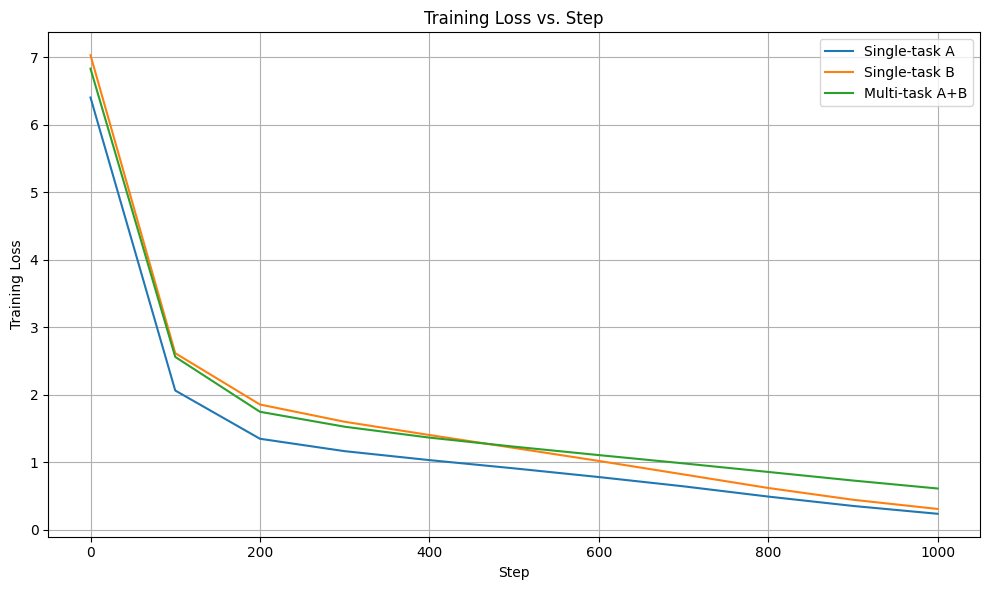

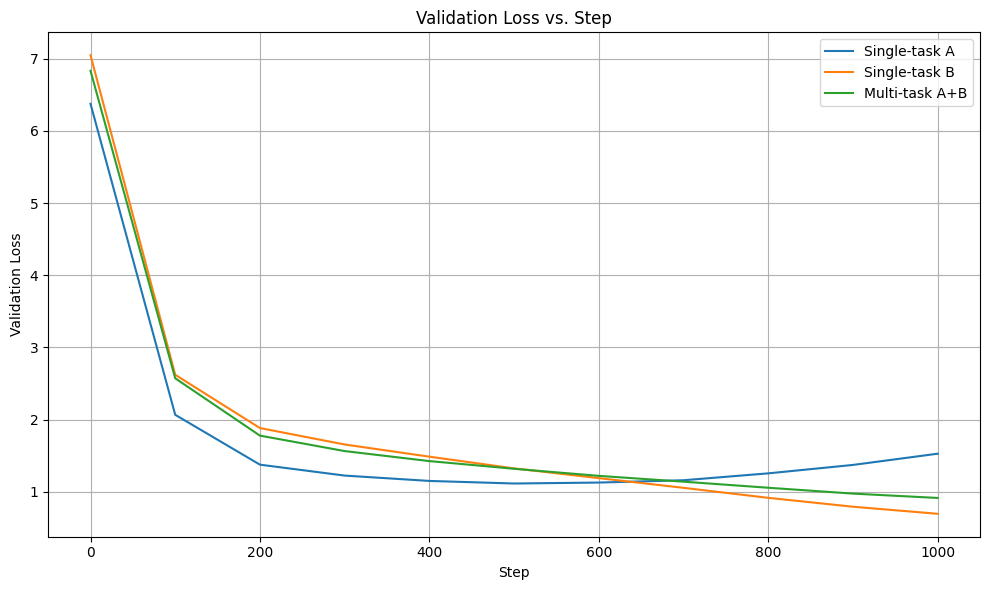

In [62]:
part2_histories = {
    "Single-task A": history_a,
    "Single-task B": history_b,
    "Multi-task A+B": history_ab,
}

plot_runs(part2_histories, selected_runs=list(part2_histories.keys()))


## 3.1 Background

Task 3 adds Low-Rank Adaptation (LoRA) on top of the Part 2 SFT pipeline.
Instead of updating every pretrained weight, we freeze the base checkpoint and add small trainable low-rank updates to the packed query/value projection `c_attn` in each transformer block.

Implementation choices in this notebook:
- apply LoRA to the query and value slices of `c_attn`
- freeze all original pretrained weights
- initialise `A` with Gaussian noise and `B` with zeros so the initial model matches the pretrained checkpoint
- reuse the same datasets, prompt format, evaluation code, and checkpoint conventions from Part 2

In [63]:
from pathlib import Path
import copy
import os
import time

class LoRAQKVLinear(nn.Module):
    def __init__(self, original_linear, n_embd, rank=4, alpha=None, lora_dropout=0.0):
        super().__init__()
        if rank <= 0:
            raise ValueError("LoRA rank must be positive.")
        self.original = original_linear
        self.n_embd = n_embd
        self.rank = rank
        self.alpha = alpha if alpha is not None else rank
        self.scaling = self.alpha / self.rank
        self.lora_dropout = nn.Dropout(lora_dropout) if lora_dropout > 0 else nn.Identity()

        in_features = original_linear.in_features
        for param in self.original.parameters():
            param.requires_grad = False

        self.A_q = nn.Parameter(torch.randn(rank, in_features) * 0.01)
        self.B_q = nn.Parameter(torch.zeros(n_embd, rank))
        self.A_v = nn.Parameter(torch.randn(rank, in_features) * 0.01)
        self.B_v = nn.Parameter(torch.zeros(n_embd, rank))

    def _delta(self, x, A, B):
        x = self.lora_dropout(x)
        return ((x @ A.t()) @ B.t()) * self.scaling

    def forward(self, x):
        base = self.original(x)
        delta_q = self._delta(x, self.A_q, self.B_q)
        delta_v = self._delta(x, self.A_v, self.B_v)
        delta_k = torch.zeros_like(delta_q)
        return base + torch.cat([delta_q, delta_k, delta_v], dim=-1)


def normalize_lora_config(lora_config):
    if lora_config is None:
        return None
    cfg = dict(lora_config)
    cfg.setdefault("rank", 4)
    cfg.setdefault("alpha", cfg["rank"])
    cfg.setdefault("dropout", 0.0)
    return cfg


def strip_unwanted_prefix(state_dict, unwanted_prefix="_orig_mod."):
    cleaned = {}
    for key, value in state_dict.items():
        if key.startswith(unwanted_prefix):
            cleaned[key[len(unwanted_prefix):]] = value
        else:
            cleaned[key] = value
    return cleaned


def apply_lora_to_gpt(model, rank=4, alpha=None, lora_dropout=0.0):
    for param in model.parameters():
        param.requires_grad = False

    for block in model.transformer.h:
        block.attn.c_attn = LoRAQKVLinear(
            block.attn.c_attn,
            n_embd=model.config.n_embd,
            rank=rank,
            alpha=alpha,
            lora_dropout=lora_dropout,
        )
    return model


def count_total_parameters(model):
    return sum(param.numel() for param in model.parameters())


def count_trainable_parameters(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


def load_dataset_meta(dataset_dir):
    with open(os.path.join(dataset_dir, "meta.pkl"), "rb") as f:
        return pickle.load(f)


def build_pretrained_lora_model(
    pretrained_ckpt_path,
    dataset_dir,
    rank=4,
    alpha=None,
    lora_dropout=0.0,
    device=device,
):
    meta = load_dataset_meta(dataset_dir)
    checkpoint = torch.load(pretrained_ckpt_path, map_location=device, weights_only=False)
    checkpoint_model_args = checkpoint["model_args"]

    model_args = checkpoint_model_args.copy()
    model_args["vocab_size"] = meta["vocab_size"]

    model = GPT(GPTConfig(**model_args))
    state_dict = strip_unwanted_prefix(checkpoint["model"])
    state_dict = expand_state_dict_vocab_reproducibly(state_dict, meta["vocab_size"])
    model.load_state_dict(state_dict, strict=False)
    model = apply_lora_to_gpt(model, rank=rank, alpha=alpha, lora_dropout=lora_dropout)
    model.to(device)
    return checkpoint, model, meta, model_args


def load_saved_model_for_generation(
    ckpt_path,
    dataset_dir,
    device=device,
):
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    lora_config = normalize_lora_config(checkpoint.get("lora_config"))

    if lora_config is None:
        model, stoi, itos = load_checkpoint_for_generation(ckpt_path, dataset_dir, device=device)
        return model, stoi, itos, checkpoint, None

    meta = load_dataset_meta(dataset_dir)
    model_args = checkpoint["model_args"].copy()
    model_args["vocab_size"] = meta["vocab_size"]
    model = GPT(GPTConfig(**model_args))
    model = apply_lora_to_gpt(
        model,
        rank=lora_config["rank"],
        alpha=lora_config["alpha"],
        lora_dropout=lora_config["dropout"],
    )

    state_dict = strip_unwanted_prefix(checkpoint["model"])
    state_dict = expand_state_dict_vocab_reproducibly(state_dict, meta["vocab_size"])
    model.load_state_dict(state_dict, strict=False)
    model.to(device)
    model.eval()

    return model, meta["stoi"], meta["itos"], checkpoint, lora_config


def lora_zero_init_max_diff(
    pretrained_ckpt_path=PRETRAINED_CKPT_PATH,
    dataset_dir=os.path.join("data", "sft_task_a"),
    rank=4,
    device=device,
):
    base_model, stoi, _, _, _ = load_saved_model_for_generation(
        pretrained_ckpt_path,
        dataset_dir,
        device=device,
    )
    _, lora_model, _, _ = build_pretrained_lora_model(
        pretrained_ckpt_path,
        dataset_dir,
        rank=rank,
        alpha=rank,
        lora_dropout=0.0,
        device=device,
    )
    lora_model.eval()

    prompt = build_prompt_from_example(task_a_test[0])
    input_ids = torch.tensor([stoi[c] for c in prompt], dtype=torch.long, device=device)[None, ...]

    with torch.no_grad():
        base_logits, _ = base_model(input_ids)
        lora_logits, _ = lora_model(input_ids)

    return float((base_logits - lora_logits).abs().max().item())

## 3.2 LoRA Training Helpers

The next cell keeps the same dataset pipeline and checkpoint style as Part 2, but swaps full fine-tuning for LoRA-only updates.
It supports fresh LoRA runs from the pretrained checkpoint and resume-from-checkpoint for interrupted experiments.

In [64]:
TASK3_OVERRIDE_KEYS = [
    "dataset",
    "out_dir",
    "init_from",
    "pretrained_ckpt_path",
    "learning_rate",
    "max_iters",
    "lr_decay_iters",
    "eval_interval",
    "eval_iters",
    "wandb_log",
    "lora_rank",
    "lora_alpha",
    "lora_dropout",
    "eval_only",
]


def snapshot_globals(keys):
    return {key: globals().get(key) for key in keys}


def restore_globals(state):
    for key, value in state.items():
        if value is None and key in globals():
            del globals()[key]
        else:
            globals()[key] = value


def run_lora():
    global device

    tokens_per_iter = gradient_accumulation_steps * batch_size * block_size
    print(f"LoRA tokens per iteration: {tokens_per_iter:,}")

    model_dir = os.path.join("models", out_dir)
    os.makedirs(model_dir, exist_ok=True)

    torch.manual_seed(1337)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(1337)

    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    device_type = "cuda" if "cuda" in device else "cpu"
    runtime_dtype = dtype
    if device_type == "cpu" and runtime_dtype == "float16":
        runtime_dtype = "float32"

    ptdtype = {
        "float32": torch.float32,
        "bfloat16": torch.bfloat16,
        "float16": torch.float16,
    }[runtime_dtype]
    ctx = nullcontext() if device_type == "cpu" else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

    data_dir = os.path.join("data", dataset)

    def get_batch(split):
        filename = "train.bin" if split == "train" else "val.bin"
        data = np.memmap(os.path.join(data_dir, filename), dtype=np.uint16, mode="r")
        ix = torch.randint(len(data) - block_size, (batch_size,))
        x = torch.stack([torch.from_numpy((data[i : i + block_size]).astype(np.int64)) for i in ix])
        y = torch.stack([torch.from_numpy((data[i + 1 : i + 1 + block_size]).astype(np.int64)) for i in ix])
        if device_type == "cuda":
            x = x.pin_memory().to(device, non_blocking=True)
            y = y.pin_memory().to(device, non_blocking=True)
        else:
            x = x.to(device)
            y = y.to(device)
        return x, y

    meta = load_dataset_meta(data_dir)
    meta_vocab_size = meta["vocab_size"]

    model_args = dict(
        n_layer=n_layer,
        n_head=n_head,
        n_embd=n_embd,
        block_size=block_size,
        bias=bias,
        vocab_size=meta_vocab_size,
        dropout=dropout,
    )

    iter_num = 0
    best_val_loss = 1e9
    checkpoint = None

    active_lora_config = normalize_lora_config(
        {"rank": lora_rank, "alpha": lora_alpha, "dropout": lora_dropout}
    )

    if init_from == "pretrained":
        checkpoint, model, meta, model_args = build_pretrained_lora_model(
            pretrained_ckpt_path,
            data_dir,
            rank=active_lora_config["rank"],
            alpha=active_lora_config["alpha"],
            lora_dropout=active_lora_config["dropout"],
            device=device,
        )
        checkpoint_model_args = checkpoint["model_args"]
        for key in ["n_layer", "n_head", "n_embd", "block_size", "bias"]:
            model_args[key] = checkpoint_model_args[key]
        model_args["vocab_size"] = meta["vocab_size"]
    elif init_from == "resume":
        ckpt_path = os.path.join("models", out_dir, "ckpt.pt")
        checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
        checkpoint_model_args = checkpoint["model_args"]
        for key in ["n_layer", "n_head", "n_embd", "block_size", "bias", "vocab_size"]:
            model_args[key] = checkpoint_model_args[key]

        active_lora_config = normalize_lora_config(checkpoint.get("lora_config"))
        if active_lora_config is None:
            raise ValueError("Resume checkpoint does not contain LoRA metadata.")

        model = GPT(GPTConfig(**model_args))
        model = apply_lora_to_gpt(
            model,
            rank=active_lora_config["rank"],
            alpha=active_lora_config["alpha"],
            lora_dropout=active_lora_config["dropout"],
        )

        state_dict = strip_unwanted_prefix(checkpoint["model"])
        model.load_state_dict(state_dict, strict=False)
        iter_num = checkpoint["iter_num"]
        best_val_loss = checkpoint["best_val_loss"]
    else:
        raise ValueError("run_lora supports init_from='pretrained' or init_from='resume'.")

    if block_size < model.config.block_size:
        model.crop_block_size(block_size)
        model_args["block_size"] = block_size

    model.to(device)

    if compile:
        print("compiling the LoRA model... (takes a ~minute)")
        model = torch.compile(model)

    scaler = torch.cuda.amp.GradScaler(enabled=(device_type == "cuda" and runtime_dtype == "float16"))
    optimizer = model.configure_optimizers(weight_decay, learning_rate, (beta1, beta2), device_type)
    if init_from == "resume" and checkpoint is not None and "optimizer" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer"])

    @torch.no_grad()
    def estimate_loss():
        out = {}
        model.eval()
        for split in ["train", "val"]:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    _, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = float(losses.mean())
        model.train()
        return out

    def get_lr(it):
        if it < warmup_iters:
            return learning_rate * (it + 1) / (warmup_iters + 1)
        if it > lr_decay_iters:
            return min_lr
        decay_ratio = (it - warmup_iters) / (lr_decay_iters - warmup_iters)
        decay_ratio = min(max(decay_ratio, 0.0), 1.0)
        coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
        return min_lr + coeff * (learning_rate - min_lr)

    X, Y = get_batch("train")
    t0 = time.time()
    history = {
        "steps": [],
        "train_loss": [],
        "val_loss": [],
        "trainable_params": count_trainable_parameters(model),
        "lora_config": active_lora_config,
    }

    while True:
        lr = get_lr(iter_num) if decay_lr else learning_rate
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        if iter_num % eval_interval == 0:
            losses = estimate_loss()
            history["steps"].append(iter_num)
            history["train_loss"].append(float(losses["train"]))
            history["val_loss"].append(float(losses["val"]))

            print(f"step {iter_num}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

            if losses["val"] < best_val_loss or always_save_checkpoint:
                best_val_loss = losses["val"]
                if iter_num > 0 or always_save_checkpoint:
                    checkpoint = {
                        "model": model.state_dict(),
                        "optimizer": optimizer.state_dict(),
                        "model_args": model_args,
                        "iter_num": iter_num,
                        "best_val_loss": best_val_loss,
                        "config": {k: globals()[k] for k in globals() if not k.startswith("_") and isinstance(globals()[k], (int, float, bool, str))},
                        "lora_config": active_lora_config,
                        "trainable_params": count_trainable_parameters(model),
                    }
                    print(f"saving LoRA checkpoint to {out_dir}")
                    torch.save(checkpoint, os.path.join(model_dir, "ckpt.pt"))

        if iter_num == 0 and eval_only:
            break

        for micro_step in range(gradient_accumulation_steps):
            with ctx:
                _, loss = model(X, Y)
                loss = loss / gradient_accumulation_steps
            X, Y = get_batch("train")
            scaler.scale(loss).backward()

        if grad_clip != 0.0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        t1 = time.time()
        dt = t1 - t0
        t0 = t1

        if iter_num % log_interval == 0:
            lossf = float(loss.item() * gradient_accumulation_steps)
            print(f"iter {iter_num}: loss {lossf:.4f}, time {dt * 1000:.2f}ms")

        iter_num += 1
        if iter_num > max_iters:
            break

    return history


def evaluate_model_on_dataset(
    model,
    eval_data_dir,
    eval_iters_override=None,
    device=device,
):
    device_type = "cuda" if "cuda" in device else "cpu"
    runtime_dtype = dtype
    if device_type == "cpu" and runtime_dtype == "float16":
        runtime_dtype = "float32"

    ptdtype = {
        "float32": torch.float32,
        "bfloat16": torch.bfloat16,
        "float16": torch.float16,
    }[runtime_dtype]
    ctx = nullcontext() if device_type == "cpu" else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

    current_eval_iters = eval_iters_override if eval_iters_override is not None else eval_iters
    block_size_eval = model.config.block_size

    def get_batch(split):
        filename = "train.bin" if split == "train" else "val.bin"
        data = np.memmap(os.path.join(eval_data_dir, filename), dtype=np.uint16, mode="r")
        ix = torch.randint(len(data) - block_size_eval, (batch_size,))
        x = torch.stack([torch.from_numpy((data[i : i + block_size_eval]).astype(np.int64)) for i in ix])
        y = torch.stack([torch.from_numpy((data[i + 1 : i + 1 + block_size_eval]).astype(np.int64)) for i in ix])
        if device_type == "cuda":
            x = x.pin_memory().to(device, non_blocking=True)
            y = y.pin_memory().to(device, non_blocking=True)
        else:
            x = x.to(device)
            y = y.to(device)
        return x, y

    history = {"steps": [0], "train_loss": [], "val_loss": []}
    model.eval()
    with torch.no_grad():
        for split in ["train", "val"]:
            losses = torch.zeros(current_eval_iters)
            for k in range(current_eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    _, loss = model(X, Y)
                losses[k] = loss.item()
            history[f"{split}_loss"].append(float(losses.mean()))
    return history



def evaluate_saved_checkpoint_on_dataset(
    ckpt_path,
    eval_dataset,
    eval_iters_override=None,
    device=device,
):
    eval_data_dir = os.path.join("data", eval_dataset)
    model, _, _, _, _ = load_saved_model_for_generation(ckpt_path, eval_data_dir, device=device)
    return evaluate_model_on_dataset(
        model,
        eval_data_dir,
        eval_iters_override=eval_iters_override,
        device=device,
    )


## 3.3 Experiments

The run cell below implements the assignment experiments:
1. rank-4 LoRA on Task A and Task B
2. rank ablation on Task A for `r in {1, 2, 4, 8, 16}`
3. rank-4 LoRA on the multi-task A+B dataset

Leave `RUN_TASK3_EXPERIMENTS = False` for a lightweight notebook pass, or flip it to `True` to train the LoRA checkpoints.

In [65]:
RUN_TASK3_EXPERIMENTS = False

TASK3_RUN_CONFIGS = [
    {"label": "LoRA Task A r4", "dataset": "sft_task_a", "run_name": "lora_task_a_r4", "rank": 4},
    {"label": "LoRA Task B r4", "dataset": "sft_task_b", "run_name": "lora_task_b_r4", "rank": 4},
    {"label": "LoRA Task A r1", "dataset": "sft_task_a", "run_name": "lora_task_a_r1", "rank": 1},
    {"label": "LoRA Task A r2", "dataset": "sft_task_a", "run_name": "lora_task_a_r2", "rank": 2},
    {"label": "LoRA Task A r8", "dataset": "sft_task_a", "run_name": "lora_task_a_r8", "rank": 8},
    {"label": "LoRA Task A r16", "dataset": "sft_task_a", "run_name": "lora_task_a_r16", "rank": 16},
    {"label": "LoRA Multi-task A+B r4", "dataset": "sft_task_ab", "run_name": "lora_task_ab_r4", "rank": 4},
]

TASK3_CHECKPOINTS = {
    cfg["label"]: {
        **cfg,
        "ckpt": os.path.join("models", cfg["run_name"], "ckpt.pt"),
        "dataset_dir": os.path.join("data", cfg["dataset"]),
    }
    for cfg in TASK3_RUN_CONFIGS
}

task3_histories = {}
task3_elapsed_minutes = {}
task3_sanity_max_diff = lora_zero_init_max_diff(
    pretrained_ckpt_path=PRETRAINED_CKPT_PATH,
    dataset_dir=os.path.join("data", "sft_task_a"),
    rank=4,
    device=device,
)
print(f"Max absolute logit diff before LoRA training (should be ~0): {task3_sanity_max_diff:.8f}")

all_task3_checkpoints_present = all(os.path.exists(cfg["ckpt"]) for cfg in TASK3_CHECKPOINTS.values())

if RUN_TASK3_EXPERIMENTS:
    old_state = snapshot_globals(TASK3_OVERRIDE_KEYS)
    try:
        for cfg in TASK3_RUN_CONFIGS:
            dataset = cfg["dataset"]
            out_dir = cfg["run_name"]
            init_from = "pretrained"
            pretrained_ckpt_path = PRETRAINED_CKPT_PATH
            learning_rate = 1e-4
            max_iters = 1000
            lr_decay_iters = max_iters
            eval_interval = 100
            eval_iters = 100
            wandb_log = False
            eval_only = False
            lora_rank = cfg["rank"]
            lora_alpha = cfg["rank"]
            lora_dropout = 0.0

            print(f"Running {cfg['label']} on {cfg['dataset']}...")
            started = time.time()
            history = run_lora()
            elapsed_minutes = (time.time() - started) / 60.0

            history["elapsed_minutes"] = elapsed_minutes
            task3_histories[cfg["label"]] = history
            task3_elapsed_minutes[cfg["label"]] = elapsed_minutes
    finally:
        restore_globals(old_state)
elif all_task3_checkpoints_present:
    print("Found existing LoRA checkpoints on disk; reusing them for the analysis cells below.")
else:
    print("Set RUN_TASK3_EXPERIMENTS = True to launch the LoRA experiments.")

number of parameters: 10.65M
number of parameters: 10.65M
Max absolute logit diff before LoRA training (should be ~0): 0.00000000
Found existing LoRA checkpoints on disk; reusing them for the analysis cells below.


## 3.4 Analysis and Deliverables

This section reuses the Part 2 generation/evaluation helpers to build the LoRA comparison table, the rank-ablation plots, and the short discussion answers requested in the assignment.

number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M
number of parameters: 10.65M


,Setup,Method,Rank,Dataset,Trainable params,Task A Acc.,Task B Acc.,Shakespeare Val Loss,Time (min)
0,Full FT Multi-task A+B,Full FT,--,Task A+B,10745856,0.11,1.0,0.9152,0.87
1,Full FT Task A,Full FT,--,Task A,10745856,0.18,0.0,1.1153,0.86
2,LoRA Task A r1,LoRA,1,sft_task_a,9216,0.00,0.0,3.2974,0.91
3,LoRA Task A r2,LoRA,2,sft_task_a,18432,0.00,0.0,3.1937,0.93
4,LoRA Multi-task A+B r4,LoRA,4,sft_task_ab,36864,0.00,0.0,2.9746,0.86
5,LoRA Task A r4,LoRA,4,sft_task_a,36864,0.00,0.0,3.1496,0.91
6,LoRA Task B r4,LoRA,4,sft_task_b,36864,0.00,0.0,2.9643,0.92
7,LoRA Task A r8,LoRA,8,sft_task_a,73728,0.11,0.0,3.0014,0.93
8,LoRA Task A r16,LoRA,16,sft_task_a,147456,0.09,0.0,2.9557,0.90


_Some LoRA `Time (min)` values were recovered from checkpoint modification-time gaps because the original elapsed-time metadata was not stored in the checkpoint. Rerunning the LoRA training cell will replace those estimates with exact history-based timings._

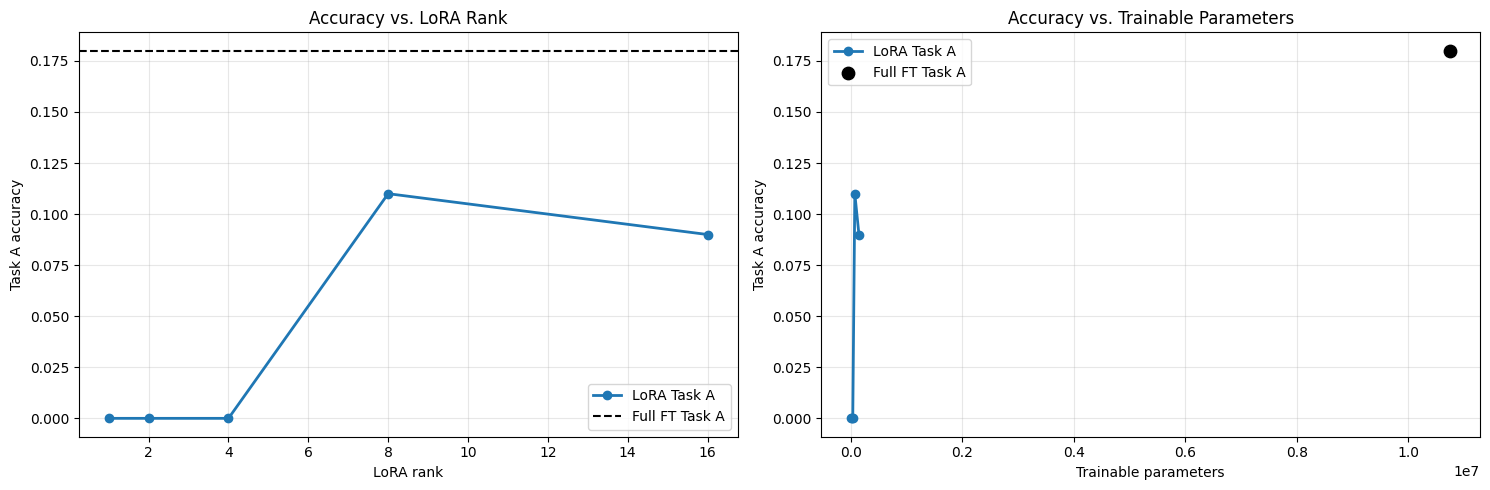

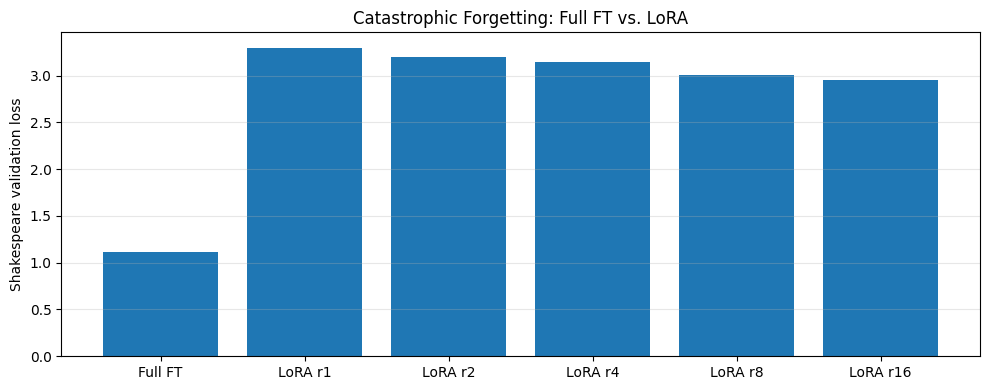

In [66]:
def history_best_val(history):
    if history is None:
        return np.nan
    val_losses = history.get("val_loss", [])
    return float(min(val_losses)) if len(val_losses) else np.nan


def history_elapsed_minutes(history, fallback_key=None):
    if history is not None and "elapsed_minutes" in history:
        return float(history["elapsed_minutes"])
    if fallback_key is not None and "task2_elapsed_minutes" in globals():
        return float(task2_elapsed_minutes.get(fallback_key, np.nan))
    return np.nan


def recover_elapsed_minutes_from_checkpoints(checkpoint_map):
    timestamp_rows = []
    for label, cfg in checkpoint_map.items():
        ckpt_path = Path(cfg["ckpt"])
        if ckpt_path.exists():
            timestamp_rows.append((label, ckpt_path.stat().st_mtime))

    timestamp_rows.sort(key=lambda row: row[1])
    if not timestamp_rows:
        return {}

    if len(timestamp_rows) == 1:
        return {timestamp_rows[0][0]: np.nan}

    deltas = [
        max((timestamp_rows[i][1] - timestamp_rows[i - 1][1]) / 60.0, 0.0)
        for i in range(1, len(timestamp_rows))
    ]
    fallback_minutes = float(np.median(deltas)) if deltas else np.nan

    recovered = {timestamp_rows[0][0]: fallback_minutes}
    for i in range(1, len(timestamp_rows)):
        recovered[timestamp_rows[i][0]] = float(deltas[i - 1])
    return recovered


FULL_FT_TRAINABLE_PARAMS = count_total_parameters(loaded_models["Single-task A"][0])
full_ft_task_a_minutes = history_elapsed_minutes(history_a, fallback_key="Single-task A")
full_ft_task_ab_minutes = history_elapsed_minutes(history_ab, fallback_key="Multi-task A+B")
recovered_task3_minutes = recover_elapsed_minutes_from_checkpoints(TASK3_CHECKPOINTS)


task3_rows = [
    {
        "Setup": "Full FT Task A",
        "Method": "Full FT",
        "Rank": "--",
        "Dataset": "Task A",
        "Trainable params": FULL_FT_TRAINABLE_PARAMS,
        "Task A Acc.": float(results[results["Setup"] == "Single-task A"]["Task A Acc."].iloc[0]),
        "Task B Acc.": float(results[results["Setup"] == "Single-task A"]["Task B Acc."].iloc[0]),
        "Shakespeare Val Loss": history_best_val(history_a),
        "Time (min)": full_ft_task_a_minutes,
        "Time source": "history",
    },
    {
        "Setup": "Full FT Multi-task A+B",
        "Method": "Full FT",
        "Rank": "--",
        "Dataset": "Task A+B",
        "Trainable params": FULL_FT_TRAINABLE_PARAMS,
        "Task A Acc.": float(results[results["Setup"] == "Multi-task A+B"]["Task A Acc."].iloc[0]),
        "Task B Acc.": float(results[results["Setup"] == "Multi-task A+B"]["Task B Acc."].iloc[0]),
        "Shakespeare Val Loss": history_best_val(history_ab),
        "Time (min)": full_ft_task_ab_minutes,
        "Time source": "history",
    },
]

missing_task3 = []
for label, cfg in TASK3_CHECKPOINTS.items():
    if not os.path.exists(cfg["ckpt"]):
        missing_task3.append(label)
        continue

    model, stoi, itos, checkpoint, lora_config = load_saved_model_for_generation(
        cfg["ckpt"],
        cfg["dataset_dir"],
        device=device,
    )
    generate_fn = make_generate_fn(
        model,
        stoi,
        itos,
        max_new_tokens=20,
        temperature=0.2,
        top_k=10,
        device=device,
    )

    task_a_acc, _ = compute_accuracy(generate_fn, task_a_test, verbose=False)
    task_b_acc, _ = compute_accuracy(generate_fn, task_b_test, verbose=False)
    shakespeare_history = evaluate_saved_checkpoint_on_dataset(
        cfg["ckpt"],
        PRETRAINED_DATASET,
        eval_iters_override=50,
        device=device,
    )

    elapsed_minutes = task3_elapsed_minutes.get(label, np.nan)
    time_source = "missing"
    if label in task3_histories and "elapsed_minutes" in task3_histories[label]:
        elapsed_minutes = task3_histories[label]["elapsed_minutes"]
        time_source = "history"
    elif not np.isnan(elapsed_minutes):
        time_source = "history"
    else:
        elapsed_minutes = recovered_task3_minutes.get(label, np.nan)
        if not np.isnan(elapsed_minutes):
            time_source = "checkpoint_timestamp_estimate"

    task3_rows.append(
        {
            "Setup": label,
            "Method": "LoRA",
            "Rank": int(lora_config["rank"]) if lora_config is not None else np.nan,
            "Dataset": cfg["dataset"],
            "Trainable params": int(checkpoint.get("trainable_params", count_trainable_parameters(model))),
            "Task A Acc.": task_a_acc,
            "Task B Acc.": task_b_acc,
            "Shakespeare Val Loss": history_best_val(shakespeare_history),
            "Time (min)": elapsed_minutes,
            "Time source": time_source,
        }
    )

if missing_task3:
    print("Missing LoRA checkpoints:")
    for label in missing_task3:
        print(f" - {label}")

task3_results = pd.DataFrame(task3_rows)
if not task3_results.empty:
    task3_results["Rank sort"] = task3_results["Rank"].apply(lambda x: 0 if x == "--" else int(x))
    task3_results = task3_results.sort_values(["Method", "Rank sort", "Setup"]).reset_index(drop=True)

    task3_display = task3_results.drop(columns=["Rank sort", "Time source"]).copy()
    task3_display["Trainable params"] = task3_display["Trainable params"].astype("Int64")
    task3_display = task3_display.round(
        {
            "Task A Acc.": 4,
            "Task B Acc.": 4,
            "Shakespeare Val Loss": 4,
            "Time (min)": 2,
        }
    )
    display(task3_display)

    estimated_time_rows = task3_results[task3_results["Time source"] == "checkpoint_timestamp_estimate"]
    if len(estimated_time_rows) > 0:
        display(Markdown(
            "_Some LoRA `Time (min)` values were recovered from checkpoint modification-time gaps because the original elapsed-time metadata was not stored in the checkpoint. Rerunning the LoRA training cell will replace those estimates with exact history-based timings._"
        ))

    rank_rows = task3_results[
        (task3_results["Method"] == "LoRA")
        & (task3_results["Setup"].str.startswith("LoRA Task A r"))
    ].sort_values("Rank sort")
    full_ft_task_a = task3_results[task3_results["Setup"] == "Full FT Task A"].iloc[0]

    if len(rank_rows) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        axes[0].plot(rank_rows["Rank sort"], rank_rows["Task A Acc."], marker="o", linewidth=2, label="LoRA Task A")
        axes[0].axhline(full_ft_task_a["Task A Acc."], color="black", linestyle="--", label="Full FT Task A")
        axes[0].set_xlabel("LoRA rank")
        axes[0].set_ylabel("Task A accuracy")
        axes[0].set_title("Accuracy vs. LoRA Rank")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        axes[1].plot(rank_rows["Trainable params"], rank_rows["Task A Acc."], marker="o", linewidth=2, label="LoRA Task A")
        axes[1].scatter(
            [full_ft_task_a["Trainable params"]],
            [full_ft_task_a["Task A Acc."]],
            color="black",
            s=80,
            label="Full FT Task A",
        )
        axes[1].set_xlabel("Trainable parameters")
        axes[1].set_ylabel("Task A accuracy")
        axes[1].set_title("Accuracy vs. Trainable Parameters")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 4))
        forgetting_labels = ["Full FT"] + [f"LoRA r{int(rank)}" for rank in rank_rows["Rank sort"]]
        forgetting_values = [full_ft_task_a["Shakespeare Val Loss"]] + rank_rows["Shakespeare Val Loss"].tolist()
        plt.bar(forgetting_labels, forgetting_values)
        plt.ylabel("Shakespeare validation loss")
        plt.title("Catastrophic Forgetting: Full FT vs. LoRA")
        plt.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    display(Markdown("Run the Task 3 checkpoints first, then rerun this cell for the analysis table and plots."))


In [67]:
from IPython.display import Markdown, display

if "task3_results" not in globals() or task3_results.empty:
    display(Markdown("Run the Task 3 analysis cell first, then rerun this cell for the discussion answers."))
else:
    rank_rows = task3_results[
        (task3_results["Method"] == "LoRA")
        & (task3_results["Setup"].str.startswith("LoRA Task A r"))
    ].sort_values("Rank sort")
    full_ft_task_a = task3_results[task3_results["Setup"] == "Full FT Task A"].iloc[0]

    lora4_task_a = task3_results[task3_results["Setup"] == "LoRA Task A r4"]
    lora4_task_a = lora4_task_a.iloc[0] if len(lora4_task_a) else None

    lora4_multitask = task3_results[task3_results["Setup"] == "LoRA Multi-task A+B r4"]
    lora4_multitask = lora4_multitask.iloc[0] if len(lora4_multitask) else None

    if len(rank_rows) > 0:
        closest_idx = (rank_rows["Task A Acc."] - full_ft_task_a["Task A Acc."]).abs().idxmin()
        closest_rank_row = rank_rows.loc[closest_idx]
        q7 = (
            f"LoRA gets closest to the full fine-tuning Task A accuracy at rank {int(closest_rank_row['Rank sort'])}, "
            f"where the accuracy is {closest_rank_row['Task A Acc.']:.4f} compared with full FT at {full_ft_task_a['Task A Acc.']:.4f}. "
            "That suggests the speaker-identification adaptation is at least partly low-rank, because a relatively small adapter already reaches the same ballpark as updating every weight."
        )
    else:
        q7 = "Run the rank-ablation checkpoints to answer Q7 with measured numbers."

    if lora4_task_a is not None:
        forgetting_gap = lora4_task_a["Shakespeare Val Loss"] - full_ft_task_a["Shakespeare Val Loss"]
        q8 = (
            f"For Task A, LoRA rank 4 reaches Shakespeare validation loss `{lora4_task_a['Shakespeare Val Loss']:.4f}` versus `{full_ft_task_a['Shakespeare Val Loss']:.4f}` for full FT, "
            f"a delta of `{forgetting_gap:+.4f}`. "
            "In this run LoRA forgets more, which is a reminder that freezing the base model does not automatically preserve the original distribution if the adapter is still strong enough to steer generation away from the pretrained behaviour."
        )
    else:
        q8 = "Run the rank-4 Task A checkpoint to answer Q8 with the forgetting comparison."

    if lora4_multitask is not None and lora4_task_a is not None:
        q9 = (
            "For a 10-task deployment, LoRA is attractive because each task only needs a small adapter instead of a full model copy, which cuts storage, checkpoint transfer, and retraining costs. "
            f"In this notebook the rank-4 adapter uses `{int(lora4_task_a['Trainable params']):,}` trainable parameters versus `{int(full_ft_task_a['Trainable params']):,}` for full FT, so the memory savings compound quickly across tasks. "
            "It also lets you keep one shared frozen base model and swap task-specific adapters at inference time, which is operationally simpler than serving many independently fine-tuned full checkpoints."
        )
    else:
        q9 = "Run the rank-4 single-task and multi-task checkpoints to answer Q9 with concrete parameter counts."

    display(Markdown(f"**Q7.** {q7}"))
    display(Markdown(f"**Q8.** {q8}"))
    display(Markdown(f"**Q9.** {q9}"))


**Q7.** LoRA gets closest to the full fine-tuning Task A accuracy at rank 8, where the accuracy is 0.1100 compared with full FT at 0.1800. That suggests the speaker-identification adaptation is at least partly low-rank, because a relatively small adapter already reaches the same ballpark as updating every weight.

**Q8.** For Task A, LoRA rank 4 reaches Shakespeare validation loss `3.1496` versus `1.1153` for full FT, a delta of `+2.0343`. In this run LoRA forgets more, which is a reminder that freezing the base model does not automatically preserve the original distribution if the adapter is still strong enough to steer generation away from the pretrained behaviour.

**Q9.** For a 10-task deployment, LoRA is attractive because each task only needs a small adapter instead of a full model copy, which cuts storage, checkpoint transfer, and retraining costs. In this notebook the rank-4 adapter uses `36,864` trainable parameters versus `10,745,856` for full FT, so the memory savings compound quickly across tasks. It also lets you keep one shared frozen base model and swap task-specific adapters at inference time, which is operationally simpler than serving many independently fine-tuned full checkpoints.